# Chat Analysis (v2-300)

This notebook mirrors the v1-30 chat analysis workflow and applies it to the full v2 run (`output/chat-v2-300`, 300 samples per model-ideology block).
It:
- loads and deduplicates per-question JSONL outputs
- checks completion / failure status against the experimental design
- reconstructs config-level Political Compass scores from stage-2 probabilities
- visualizes ideological positions and uncertainty
- runs factor-sensitivity ANOVA with a sample-size-aware setting (`detailed` for `n >= 300`)
- adds diagnostics for token lengths, reasoning mode, and think / no_think comparisons

In [1]:
import json
import math
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

warnings.filterwarnings('ignore')

ROOT = Path('.')
RESULTS_DIR = ROOT / 'output' / 'chat-v2-300'
DESIGN_PATH = RESULTS_DIR / 'experimental_design.csv'
PARAMS_PATH = ROOT / 'scorer.npz'
QUESTIONS_PATH = ROOT / 'data' / 'questions' / 'english.json'
PLOTS_DIR = RESULTS_DIR / 'analysis_plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_QUESTIONS = 62
DISPLAY_NAMES = {
    'base': 'Base Model',
    'authoritarian_left': 'Auth Left',
    'authoritarian_right': 'Auth Right',
    'libertarian_left': 'Lib Left',
    'libertarian_right': 'Lib Right',
    'centrism': 'Centrism',
}
IDEOLOGY_COLORS = {
    'Base Model': '#555555',
    'Auth Left': '#d62728',
    'Auth Right': '#1f77b4',
    'Lib Left': '#2ca02c',
    'Lib Right': '#9467bd',
    'Centrism': '#7f7f7f',
}
FACTOR_LABELS = {
    'context_combo': 'Context',
    'instr_combo': 'Instruction',
    'reasoning_mode': 'Reasoning Mode',
    'persona_combo': 'Persona',
    'key_type': 'Key Type',
    'perm_id': 'Permutation',
    'suffix_idx': 'Suffix',
}

GENERAL_MODEL_ORDER_1 = [
    # row 1
    'gemma-3-1b-it',
    'gemma-3-4b-it',
    'gemma-3-12b-it',
    'gemma-3-27b-it',
    # row 2
    'Qwen3-4B_no_think',
    'Qwen3-8B_no_think',
    'Qwen3-14B_no_think',
    'Qwen3-32B_no_think',
    # row 3
    'Qwen3-4B_think',
    'Qwen3-8B_think',
    'Qwen3-14B_think',
    'Qwen3-32B_think',
]

GENERAL_MODEL_ORDER_2 = [
    # row 1
    'GaMS-2B-Instruct',
    'GaMS-9B-Instruct',
    'GaMS-27B-Instruct',
    # row 2
    'GaMS-9B-Instruct-Nemotron',
    'GaMS-27B-Instruct-Nemotron',
    'gemma-3-27b-it-abliterated-normpreserve-v1',
    # row 3
    'gemma-3-4b-it',
    'gemma-3-12b-it',
    'gemma-3-27b-it',
]

GENERAL_MODEL_ORDER = list(dict.fromkeys(GENERAL_MODEL_ORDER_1 + GENERAL_MODEL_ORDER_2))

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 7)

# Sanity check on raw artifacts before any analysis work.
if not DESIGN_PATH.exists():
    raise FileNotFoundError(f'Missing design file: {DESIGN_PATH}')
if not QUESTIONS_PATH.exists():
    raise FileNotFoundError(f'Missing questions file: {QUESTIONS_PATH}')

jsonl_paths = sorted(RESULTS_DIR.glob('*.jsonl'))
if not jsonl_paths:
    raise RuntimeError(f'No JSONL outputs found in {RESULTS_DIR}')

design_df_sanity = pd.read_csv(DESIGN_PATH)
config_ids_sanity = set(design_df_sanity['config_id'].astype(int).tolist())
question_ids_sanity = {
    int(q['id'])
    for q in json.loads(QUESTIONS_PATH.read_text(encoding='utf-8'))
}
expected_total_items = len(config_ids_sanity) * len(question_ids_sanity)

item_id_pattern = re.compile(r'^cfg(?P<cfg>\d+)_q(?P<qid>\d+)$')
observed_pairs = set()
raw_rows = 0
invalid_item_ids = 0
invalid_examples = []

for path in jsonl_paths:
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            raw_rows += 1
            row = json.loads(line)
            item_id = str(row.get('item_id', ''))
            match = item_id_pattern.match(item_id)
            if match is None:
                invalid_item_ids += 1
                if len(invalid_examples) < 5:
                    invalid_examples.append(item_id)
                continue
            cfg_id = int(match.group('cfg'))
            qid = int(match.group('qid'))
            if cfg_id not in config_ids_sanity or qid not in question_ids_sanity:
                invalid_item_ids += 1
                if len(invalid_examples) < 5:
                    invalid_examples.append(item_id)
                continue
            observed_pairs.add((cfg_id, qid))

observed_total_items = len(observed_pairs)
missing_total_items = expected_total_items - observed_total_items
duplicate_or_retry_rows = raw_rows - observed_total_items

print('Sanity check (raw JSONL coverage)')
print(f'- JSONL files found             : {len(jsonl_paths)}')
print(f'- Expected unique item_ids      : {expected_total_items:,}')
print(f'- Observed unique valid item_ids: {observed_total_items:,}')
print(f'- Missing expected item_ids     : {missing_total_items:,}')
print(f'- Duplicate/retry rows          : {duplicate_or_retry_rows:,}')
print(f'- Invalid item_id rows          : {invalid_item_ids:,}')

if invalid_item_ids > 0 or missing_total_items != 0:
    raise AssertionError(
        'Raw artifact sanity check failed: '
        f'missing={missing_total_items}, invalid={invalid_item_ids}, '
        f'invalid_examples={invalid_examples}'
    )

Sanity check (raw JSONL coverage)
- JSONL files found             : 22
- Expected unique item_ids      : 2,455,200
- Observed unique valid item_ids: 2,455,200
- Missing expected item_ids     : 0
- Duplicate/retry rows          : 0
- Invalid item_id rows          : 0


In [2]:
def get_model_sort_key(name: str):
    name = str(name)
    if name in GENERAL_MODEL_ORDER:
        return (0, GENERAL_MODEL_ORDER.index(name), name)

    lower = name.lower()
    family_rank = 3
    if 'gemma' in lower:
        family_rank = 0
    elif 'qwen' in lower:
        family_rank = 1
    elif 'gams' in lower:
        family_rank = 2

    size_match = re.search(r'(\d+(?:\.\d+)?)[Bb]', name)
    size = float(size_match.group(1)) if size_match else 0.0

    mode_rank = 0
    if name.endswith('_no_think'):
        mode_rank = 1
    elif name.endswith('_think'):
        mode_rank = 2

    return (1, family_rank, size, mode_rank, name)


def ordered_model_variants(values, order='general'):
    if order == 'group1':
        preferred = GENERAL_MODEL_ORDER_1
    elif order == 'group2':
        preferred = GENERAL_MODEL_ORDER_2
    elif order == 'factor':
        preferred = GENERAL_MODEL_ORDER
    else:
        preferred = GENERAL_MODEL_ORDER

    seen = []
    for value in values:
        if pd.isna(value):
            continue
        value = str(value)
        if value not in seen:
            seen.append(value)

    ordered = [value for value in preferred if value in seen]
    extras = sorted([value for value in seen if value not in set(ordered)], key=get_model_sort_key)
    return ordered + extras


def base_model_name(model_variant: str) -> str:
    model_variant = str(model_variant)
    for suffix in ['_think', '_no_think']:
        if model_variant.endswith(suffix):
            return model_variant[:-len(suffix)]
    return model_variant


def short_model_label(model_name: str) -> str:
    model_name = str(model_name)
    size_match = re.search(r'(\d+(?:\.\d+)?)[Bb]', model_name)
    size = f"{size_match.group(1)}B" if size_match else model_name
    if model_name.endswith('_no_think'):
        return f"{size} no_think"
    if model_name.endswith('_think'):
        return f"{size} think"
    return size


def display_model_label(model_name: str) -> str:
    model_name = str(model_name)
    size_match = re.search(r'(\d+(?:\.\d+)?)[Bb]', model_name)
    size = f"{size_match.group(1)}B" if size_match else model_name

    if model_name.startswith('Qwen3-'):
        if model_name.endswith('_no_think'):
            return f"Qwen {size} no_think"
        if model_name.endswith('_think'):
            return f"Qwen {size} think"
        return f"Qwen {size}"

    if model_name.startswith('gemma-3-'):
        if 'abliterated' in model_name:
            return f"Gemma {size} abl"
        return f"Gemma {size}"

    if model_name.startswith('GaMS-'):
        if 'Nemotron' in model_name:
            return f"GaMS {size} N"
        return f"GaMS {size}"

    return model_name


def draw_background(ax):
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect('equal')
    ax.add_patch(patches.Rectangle((-10, 0), 10, 10, fc='#ff3333', alpha=0.08))
    ax.add_patch(patches.Rectangle((0, 0), 10, 10, fc='#3399ff', alpha=0.08))
    ax.add_patch(patches.Rectangle((-10, -10), 10, 10, fc='#33ff33', alpha=0.08))
    ax.add_patch(patches.Rectangle((0, -10), 10, 10, fc='#b366ff', alpha=0.08))
    ax.axhline(0, color='black', lw=1)
    ax.axvline(0, color='black', lw=1)
    ax.set_xticks(range(-10, 11, 5))
    ax.set_yticks(range(-10, 11, 5))
    ax.tick_params(labelsize=9)


def confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):
    x = np.asarray(x)
    y = np.asarray(y)
    if x.size < 2 or y.size < 2:
        return None
    cov = np.cov(x, y)
    if np.any(~np.isfinite(cov)):
        return None
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 1e-12))
    ell = Ellipse((np.mean(x), np.mean(y)), width, height, angle=angle, facecolor=facecolor, **kwargs)
    ax.add_patch(ell)
    return ell


def simplify_error(err):
    if pd.isna(err) or err in (None, ''):
        return 'success'
    err = str(err)
    if 'OutOfMemoryError' in err or 'CUDA out of memory' in err:
        return 'oom'
    if 'EngineCore encountered an issue' in err:
        return 'engine_core'
    if 'classification_generate_failed' in err:
        return 'classification_generate'
    if 'missing_prompt_logprob_for_candidate' in err:
        return 'missing_prompt_logprob'
    if 'candidate_key_tokenized_to_empty_suffix_in_context' in err:
        return 'tokenization_suffix'
    if 'worker_config_failed' in err:
        return 'worker_config_failed'
    if 'stage1_generation_failed' in err:
        return 'stage1_generation_failed'
    return 'other'

In [3]:
def load_latest_chat_records(results_dir: Path) -> pd.DataFrame:
    latest = {}
    for path in sorted(results_dir.glob('*.jsonl')):
        with path.open('r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                row = json.loads(line)
                latest[row['item_id']] = row
    df = pd.DataFrame(latest.values())
    if df.empty:
        raise RuntimeError(f'No JSONL rows found in {results_dir}')
    return df


def add_probability_columns(item_df: pd.DataFrame) -> pd.DataFrame:
    df = item_df.copy()
    for ans_idx in range(4):
        df[f'prob_ans{ans_idx}'] = np.nan
    for idx, row in df.iterrows():
        probs = row.get('classification_probs') or {}
        keys = row.get('candidate_keys') or []
        for ans_idx, key in enumerate(keys[:4]):
            value = probs.get(key, np.nan)
            try:
                df.at[idx, f'prob_ans{ans_idx}'] = float(value)
            except Exception:
                df.at[idx, f'prob_ans{ans_idx}'] = np.nan
    return df


def build_config_level_frame(item_df: pd.DataFrame) -> pd.DataFrame:
    meta_cols = [
        'config_id', 'model', 'model_variant', 'generation_mode', 'language', 'ideology',
        'context_id', 'instr_type', 'reasoning_mode', 'instr_idx', 'persona_class', 'persona_idx',
        'key_type', 'perm_id', 'suffix_idx', 'answer_mode', 'inference_backend', 'quantization'
    ]
    records = []
    for config_id, sub in item_df.groupby('config_id', sort=True):
        first = sub.iloc[0]
        row = {col: first.get(col) for col in meta_cols}
        row['n_items'] = len(sub)
        row['n_success_items'] = int(sub['error'].isna().sum())
        row['n_failed_items'] = int(sub['error'].notna().sum())
        row['mean_stage1_tokens'] = float(sub['stage1_tokens'].fillna(0).mean())
        row['complete_success'] = row['n_success_items'] == EXPECTED_QUESTIONS
        row['error_families'] = sorted(set(sub['error_family']))
        for _, qrow in sub.iterrows():
            qid = int(qrow['question_id'])
            for ans_idx in range(4):
                row[f'q{qid}_prob_ans{ans_idx}'] = qrow.get(f'prob_ans{ans_idx}', np.nan)
        records.append(row)
    return pd.DataFrame(records)


raw_item_df = load_latest_chat_records(RESULTS_DIR)
item_df = raw_item_df.copy()
item_df['error_family'] = item_df['error'].apply(simplify_error)
item_df['base_model'] = item_df['model_variant'].apply(base_model_name)
item_df['ideology_label'] = item_df['ideology'].map(DISPLAY_NAMES)
item_df = add_probability_columns(item_df)
config_df = build_config_level_frame(item_df)

questions = json.loads(QUESTIONS_PATH.read_text(encoding='utf-8'))
design_df = pd.read_csv(DESIGN_PATH)
expected_total_items = int(design_df['config_id'].nunique()) * len(questions)
observed_total_items = int(item_df['item_id'].nunique())
success_total_items = int(item_df['error'].isna().sum())

if observed_total_items != expected_total_items:
    raise AssertionError(
        f'Latest-row coverage mismatch: observed={observed_total_items:,}, expected={expected_total_items:,}'
    )
if success_total_items != expected_total_items:
    raise AssertionError(
        f'Not all expected items succeeded: success={success_total_items:,}, expected={expected_total_items:,}'
    )

print(f'Loaded {len(item_df):,} latest question-level rows')
print(f'Loaded {len(config_df):,} config-level rows')
print(f'Question count in source file: {len(questions)}')
print(f'Sanity check (latest rows): {success_total_items:,}/{expected_total_items:,} successful items')

models_in_run = sorted(item_df['model_variant'].astype(str).unique(), key=get_model_sort_key)
print(f'Model variants in run: {len(models_in_run)}')
print(models_in_run)

run_summary = (
    item_df.groupby('model_variant', sort=False)
    .agg(
        total_items=('item_id', 'count'),
        success_items=('error', lambda s: int(s.isna().sum())),
        failed_items=('error', lambda s: int(s.notna().sum())),
        mean_stage1_tokens=('stage1_tokens', 'mean'),
        median_stage1_tokens=('stage1_tokens', 'median'),
    )
    .reset_index()
)
run_summary['success_rate'] = run_summary['success_items'] / run_summary['total_items']
run_order = ordered_model_variants(run_summary['model_variant'].unique(), order='general')
run_summary = (
    run_summary.assign(model_variant=pd.Categorical(run_summary['model_variant'], categories=run_order, ordered=True))
    .sort_values('model_variant')
    .reset_index(drop=True)
)
run_summary['model_variant'] = run_summary['model_variant'].astype(str)
run_summary

Loaded 2,455,200 latest question-level rows
Loaded 39,600 config-level rows
Question count in source file: 62
Sanity check (latest rows): 2,455,200/2,455,200 successful items
Model variants in run: 22
['gemma-3-1b-it', 'gemma-3-4b-it', 'gemma-3-12b-it', 'gemma-3-27b-it', 'Qwen3-4B_no_think', 'Qwen3-8B_no_think', 'Qwen3-14B_no_think', 'Qwen3-32B_no_think', 'Qwen3-4B_think', 'Qwen3-8B_think', 'Qwen3-14B_think', 'Qwen3-32B_think', 'GaMS-2B-Instruct', 'GaMS-9B-Instruct', 'GaMS-27B-Instruct', 'GaMS-9B-Instruct-Nemotron', 'GaMS-27B-Instruct-Nemotron', 'gemma-3-27b-it-abliterated-normpreserve-v1', 'Qwen3-0.6B_no_think', 'Qwen3-0.6B_think', 'Qwen3-1.7B_no_think', 'Qwen3-1.7B_think']


,model_variant,total_items,success_items,failed_items,mean_stage1_tokens,median_stage1_tokens,success_rate
0,gemma-3-1b-it,111600,111600,0,129.724140,71.0,1.0
1,gemma-3-4b-it,111600,111600,0,203.082070,141.0,1.0
2,gemma-3-12b-it,111600,111600,0,242.863011,164.0,1.0
3,gemma-3-27b-it,111600,111600,0,239.547634,195.0,1.0
4,Qwen3-4B_no_think,111600,111600,0,152.240081,109.0,1.0
5,Qwen3-8B_no_think,111600,111600,0,165.222634,116.0,1.0
6,Qwen3-14B_no_think,111600,111600,0,147.398306,110.0,1.0
7,Qwen3-32B_no_think,111600,111600,0,144.660484,112.0,1.0
8,Qwen3-4B_think,111600,111600,0,717.043217,613.0,1.0
9,Qwen3-8B_think,111600,111600,0,723.842321,626.0,1.0


In [4]:
design_df = pd.read_csv(DESIGN_PATH)

print('Experimental design summary (chat-v2-300)')
print('  Configs           :', len(design_df))
print('  Languages         :', sorted(design_df['language'].dropna().astype(str).unique()))
print('  Model variants    :', len(design_df['model_variant'].unique()))
print('  Ideologies        :', sorted(design_df['ideology'].unique()))
print('  Instruction types :', sorted(design_df['instr_type'].unique()))
print('  Reasoning modes   :', sorted(design_df['reasoning_mode'].dropna().astype(str).unique()))
print('  key_type values   :', sorted(design_df['key_type'].unique()))
print('  perm_id values    :', sorted(design_df['perm_id'].astype(int).unique()))
print('  suffix_idx values :', sorted(design_df['suffix_idx'].astype(int).unique()))

persona_counts = item_df['persona_class'].fillna('').value_counts().sort_index()
print('Question-level persona_class counts:')
print(persona_counts)

mode_counts = item_df['reasoning_mode'].fillna('neutral').value_counts().sort_index()
print('Question-level reasoning_mode counts:')
print(mode_counts)

CHAT_SAMPLES_PER_BLOCK = int(design_df.groupby(['model_variant', 'ideology']).size().mode().iloc[0])
print(f'Detected samples per model-ideology block: {CHAT_SAMPLES_PER_BLOCK}')

print('Expected for one model_variant block:')
print(f'- base configs have no persona -> {CHAT_SAMPLES_PER_BLOCK} * {EXPECTED_QUESTIONS} = {CHAT_SAMPLES_PER_BLOCK * EXPECTED_QUESTIONS} items')
print(f'- non-base configs total       -> {5 * CHAT_SAMPLES_PER_BLOCK} * {EXPECTED_QUESTIONS} = {5 * CHAT_SAMPLES_PER_BLOCK * EXPECTED_QUESTIONS} items')

coverage = (
    config_df.groupby('model_variant')
    .agg(
        total_configs=('config_id', 'count'),
        complete_success_configs=('complete_success', 'sum'),
        partial_or_failed_configs=('complete_success', lambda s: int((~s).sum())),
    )
    .reset_index()
)
coverage['config_completion_rate'] = coverage['complete_success_configs'] / coverage['total_configs']
coverage_order = ordered_model_variants(coverage['model_variant'].unique(), order='general')
coverage = (
    coverage.assign(model_variant=pd.Categorical(coverage['model_variant'], categories=coverage_order, ordered=True))
    .sort_values('model_variant')
    .reset_index(drop=True)
)
coverage['model_variant'] = coverage['model_variant'].astype(str)
coverage

Experimental design summary (chat-v2-300)
  Configs           : 39600
  Languages         : ['english']
  Model variants    : 22
  Ideologies        : ['authoritarian_left', 'authoritarian_right', 'base', 'centrism', 'libertarian_left', 'libertarian_right']
  Instruction types : ['options_first', 'question_first']
  Reasoning modes   : ['neutral', 'short', 'think']
  key_type values   : ['lowercase_start', 'numeric', 'numeric_zero_index', 'uppercase_start']
  perm_id values    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  suffix_idx values : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Question-level persona_class counts:
persona_class
          409200
long     1023000
short    1023000
Name: count, dtype: int64
Question-level reasoning_mode counts:
reasoning_mode
neutral    818400
short      818400
think      818400
Name: count, dtype: int64
Detected samples per model-ideology block: 300
Expected for one model_variant block:
- base configs have no person

,model_variant,total_configs,complete_success_configs,partial_or_failed_configs,config_completion_rate
0,gemma-3-1b-it,1800,1800,0,1.0
1,gemma-3-4b-it,1800,1800,0,1.0
2,gemma-3-12b-it,1800,1800,0,1.0
3,gemma-3-27b-it,1800,1800,0,1.0
4,Qwen3-4B_no_think,1800,1800,0,1.0
5,Qwen3-8B_no_think,1800,1800,0,1.0
6,Qwen3-14B_no_think,1800,1800,0,1.0
7,Qwen3-32B_no_think,1800,1800,0,1.0
8,Qwen3-4B_think,1800,1800,0,1.0
9,Qwen3-8B_think,1800,1800,0,1.0


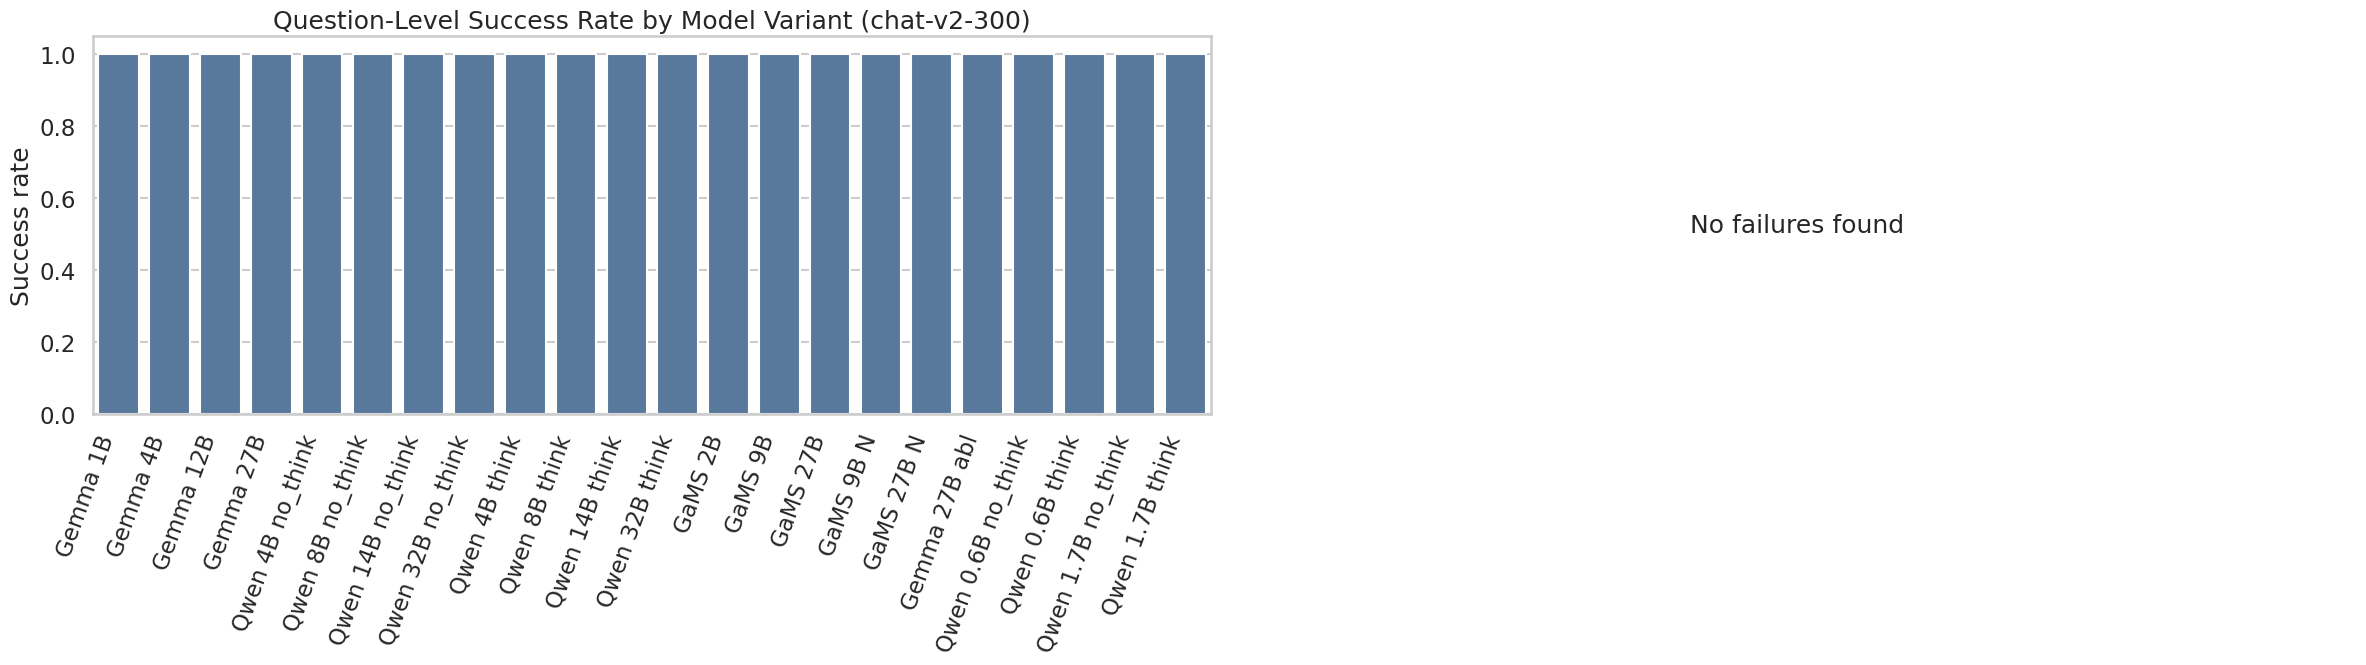

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(24, 7))

plot_df = run_summary.copy()
order = ordered_model_variants(plot_df['model_variant'].unique(), order='general')
sns.barplot(data=plot_df, x='model_variant', y='success_rate', order=order, color='#4c78a8', ax=axes[0])
axes[0].set_title('Question-Level Success Rate by Model Variant (chat-v2-300)')
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel('')
axes[0].set_ylabel('Success rate')
axes[0].tick_params(axis='x', rotation=70)
axes[0].set_xticklabels([display_model_label(v) for v in order], ha='right')

error_plot = (
    item_df[item_df['error'].notna()]
    .groupby(['model_variant', 'error_family'])
    .size()
    .reset_index(name='count')
)
if not error_plot.empty:
    pivot = error_plot.pivot(index='model_variant', columns='error_family', values='count').fillna(0)
    pivot = pivot.reindex([v for v in order if v in pivot.index])
    sns.heatmap(
        np.log10(pivot + 1),
        cmap='magma',
        ax=axes[1],
        cbar_kws={'label': 'log10(count + 1)'},
        yticklabels=[display_model_label(v) for v in pivot.index],
    )
    axes[1].set_title('Failure Modes by Model Variant (chat-v2-300)')
    axes[1].set_xlabel('Error family')
    axes[1].set_ylabel('')
    axes[1].tick_params(axis='y', labelsize=9)
else:
    axes[1].text(0.5, 0.5, 'No failures found', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_completion_and_failures.png', dpi=200, bbox_inches='tight')
plt.show()

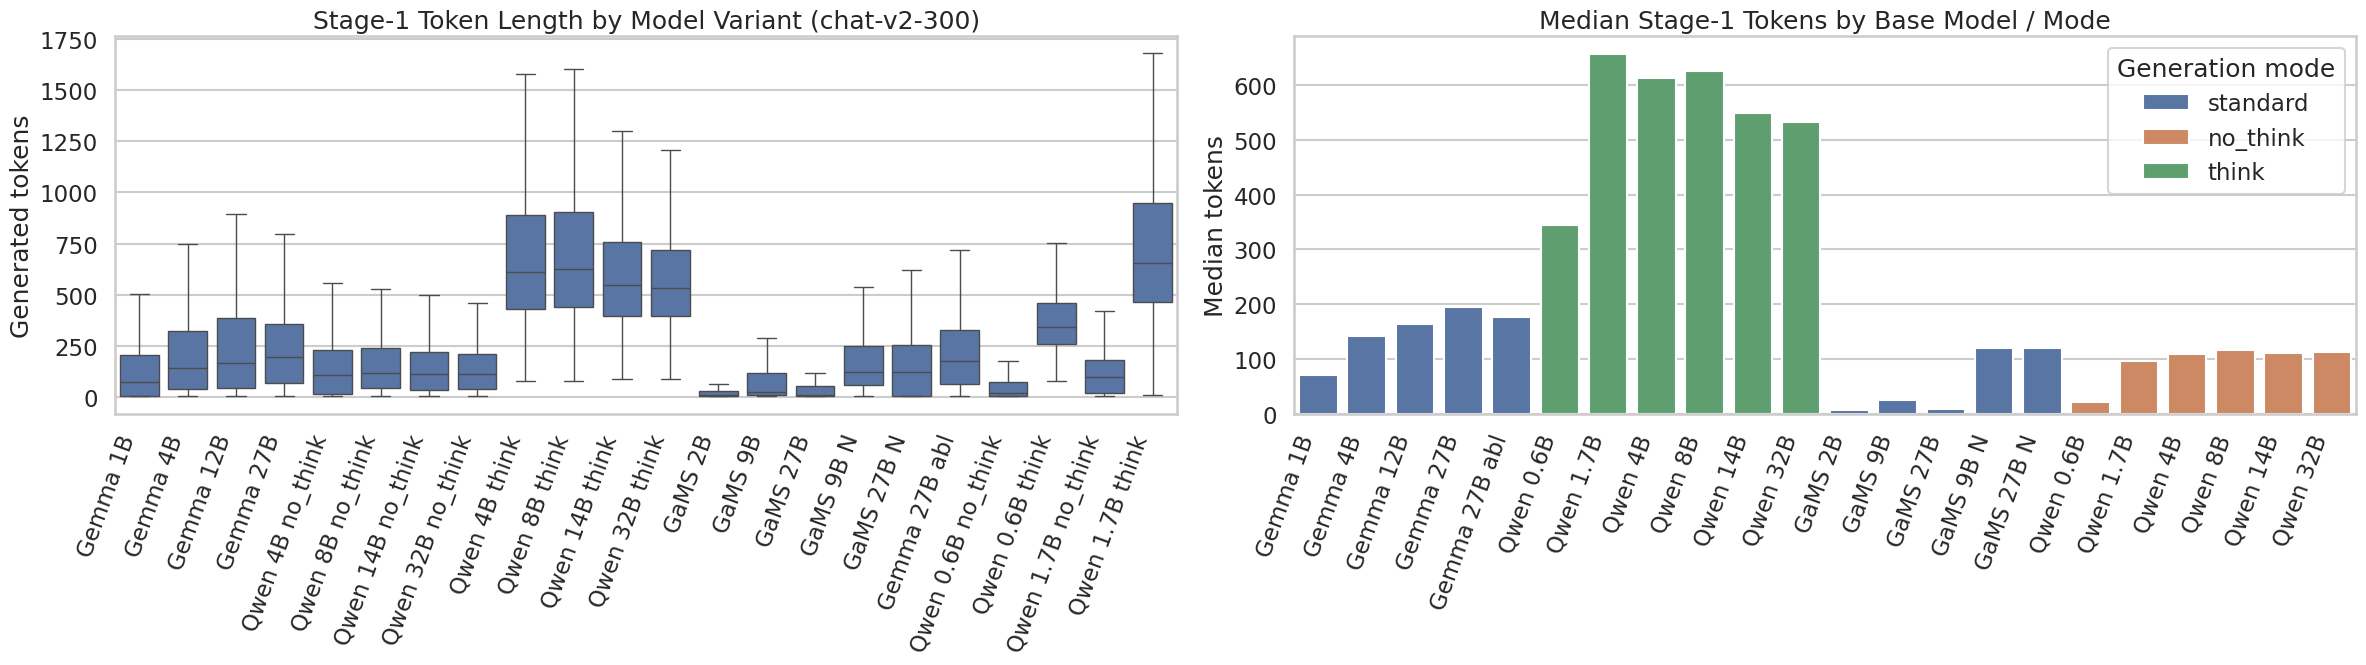

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(24, 7))

success_tokens = item_df[item_df['error'].isna()].copy()
success_tokens['mode_label'] = success_tokens['generation_mode'].fillna('standard')
order = ordered_model_variants(success_tokens['model_variant'].unique(), order='general')

sns.boxplot(
    data=success_tokens,
    x='model_variant',
    y='stage1_tokens',
    order=order,
    showfliers=False,
    ax=axes[0],
)
axes[0].set_title('Stage-1 Token Length by Model Variant (chat-v2-300)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Generated tokens')
axes[0].tick_params(axis='x', rotation=70)
axes[0].set_xticklabels([display_model_label(v) for v in order], ha='right')

mode_tokens = (
    success_tokens.groupby(['base_model', 'generation_mode'])['stage1_tokens']
    .median()
    .reset_index()
)
if not mode_tokens.empty:
    preferred_base_order = [
        'gemma-3-1b-it',
        'gemma-3-4b-it',
        'gemma-3-12b-it',
        'gemma-3-27b-it',
        'gemma-3-27b-it-abliterated-normpreserve-v1',
        'Qwen3-0.6B',
        'Qwen3-1.7B',
        'Qwen3-4B',
        'Qwen3-8B',
        'Qwen3-14B',
        'Qwen3-32B',
        'GaMS-2B-Instruct',
        'GaMS-9B-Instruct',
        'GaMS-27B-Instruct',
        'GaMS-9B-Instruct-Nemotron',
        'GaMS-27B-Instruct-Nemotron',
    ]
    base_order = [b for b in preferred_base_order if b in set(mode_tokens['base_model'])]
    extras = sorted([b for b in mode_tokens['base_model'].unique() if b not in set(base_order)], key=get_model_sort_key)
    base_order = base_order + extras
    hue_order = [h for h in ['standard', 'neutral', 'no_think', 'short', 'think'] if h in set(mode_tokens['generation_mode'])]

    sns.barplot(
        data=mode_tokens,
        x='base_model',
        y='stage1_tokens',
        hue='generation_mode',
        order=base_order,
        hue_order=hue_order,
        ax=axes[1],
    )
    axes[1].set_title('Median Stage-1 Tokens by Base Model / Mode')
    axes[1].set_xlabel('')
    axes[1].set_ylabel('Median tokens')
    axes[1].tick_params(axis='x', rotation=70)
    axes[1].set_xticklabels([display_model_label(v) for v in base_order], ha='right')
    axes[1].legend(title='Generation mode')
else:
    axes[1].text(0.5, 0.5, 'No token data available', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(PLOTS_DIR / '02_stage1_token_lengths.png', dpi=200, bbox_inches='tight')
plt.show()

In [7]:
params = np.load(PARAMS_PATH)
W_ECON = params['weights_economic']
W_SOC = params['weights_social']
B_ECON = float(params['bias_economic'])
B_SOC = float(params['bias_social'])
NUM_QUESTIONS = int(W_ECON.shape[0])


def prepare_factors(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['context_combo'] = out['context_id'].apply(lambda x: 'None' if pd.isna(x) or int(x) == -1 else f'Ctx_{int(x)}')
    out['instr_combo'] = out['instr_type'].astype(str) + '_idx' + out['instr_idx'].astype(int).astype(str)
    out['reasoning_mode'] = out['reasoning_mode'].fillna('neutral').astype(str)
    out['persona_combo'] = out.apply(
        lambda row: 'None' if str(row.get('persona_class', '')).strip() == '' else f"{row['persona_class']}_idx{int(row['persona_idx'])}",
        axis=1,
    )
    out['perm_id'] = out['perm_id'].astype(int)
    out['suffix_idx'] = out['suffix_idx'].astype(int)
    return out


def calculate_intrinsic_variance(df, weights, num_q):
    total_intrinsic_var = np.zeros(len(df))
    is_reversed = df['perm_id'].astype(int).isin([2, 3]).values
    for q_idx in range(num_q):
        cols = [f'q{q_idx}_prob_ans{a}' for a in range(4)]
        if not all(c in df.columns for c in cols):
            continue
        probs = df[cols].values.astype(float)
        q_w = weights[q_idx, :]
        row_weights = np.tile(q_w, (len(df), 1))
        row_weights[is_reversed] = q_w[::-1]
        e_w = np.sum(probs * row_weights, axis=1)
        e_w2 = np.sum(probs * (row_weights ** 2), axis=1)
        total_intrinsic_var += (e_w2 - (e_w ** 2))
    return total_intrinsic_var


def calculate_scores_with_debias(df, W_ECON, W_SOC, B_ECON, B_SOC, num_q):
    out = df.copy()
    econ_scores = np.zeros(len(out)) + B_ECON
    soc_scores = np.zeros(len(out)) + B_SOC
    is_reversed = out['perm_id'].astype(int).isin([2, 3]).values
    for q_idx in range(num_q):
        cols = [f'q{q_idx}_prob_ans{a}' for a in range(4)]
        if not all(c in out.columns for c in cols):
            continue
        probs = out[cols].values.astype(float)
        corrected = probs.copy()
        corrected[is_reversed] = probs[is_reversed][:, ::-1]
        econ_scores += np.dot(corrected, W_ECON[q_idx, :])
        soc_scores += np.dot(corrected, W_SOC[q_idx, :])
    out['score_econ'] = econ_scores
    out['score_soc'] = soc_scores
    out['intrinsic_var_econ'] = calculate_intrinsic_variance(out, W_ECON, num_q)
    out['intrinsic_var_soc'] = calculate_intrinsic_variance(out, W_SOC, num_q)
    return out


successful_configs = config_df[config_df['complete_success']].copy()
score_df = calculate_scores_with_debias(prepare_factors(successful_configs), W_ECON, W_SOC, B_ECON, B_SOC, NUM_QUESTIONS)
print('Successful configs used for scoring:', len(score_df))
print('Dropped configs due to incomplete success:', len(config_df) - len(successful_configs))
score_df[['model_variant', 'ideology', 'reasoning_mode', 'score_econ', 'score_soc']].head()

Successful configs used for scoring: 39600
Dropped configs due to incomplete success: 0


,model_variant,ideology,reasoning_mode,score_econ,score_soc
0,gemma-3-1b-it,base,short,2.652851,0.955321
1,gemma-3-1b-it,base,think,0.251316,-3.739135
2,gemma-3-1b-it,base,neutral,-0.225279,-1.486200
3,gemma-3-1b-it,base,think,-1.846010,-0.778877
4,gemma-3-1b-it,base,neutral,-0.605443,3.289866


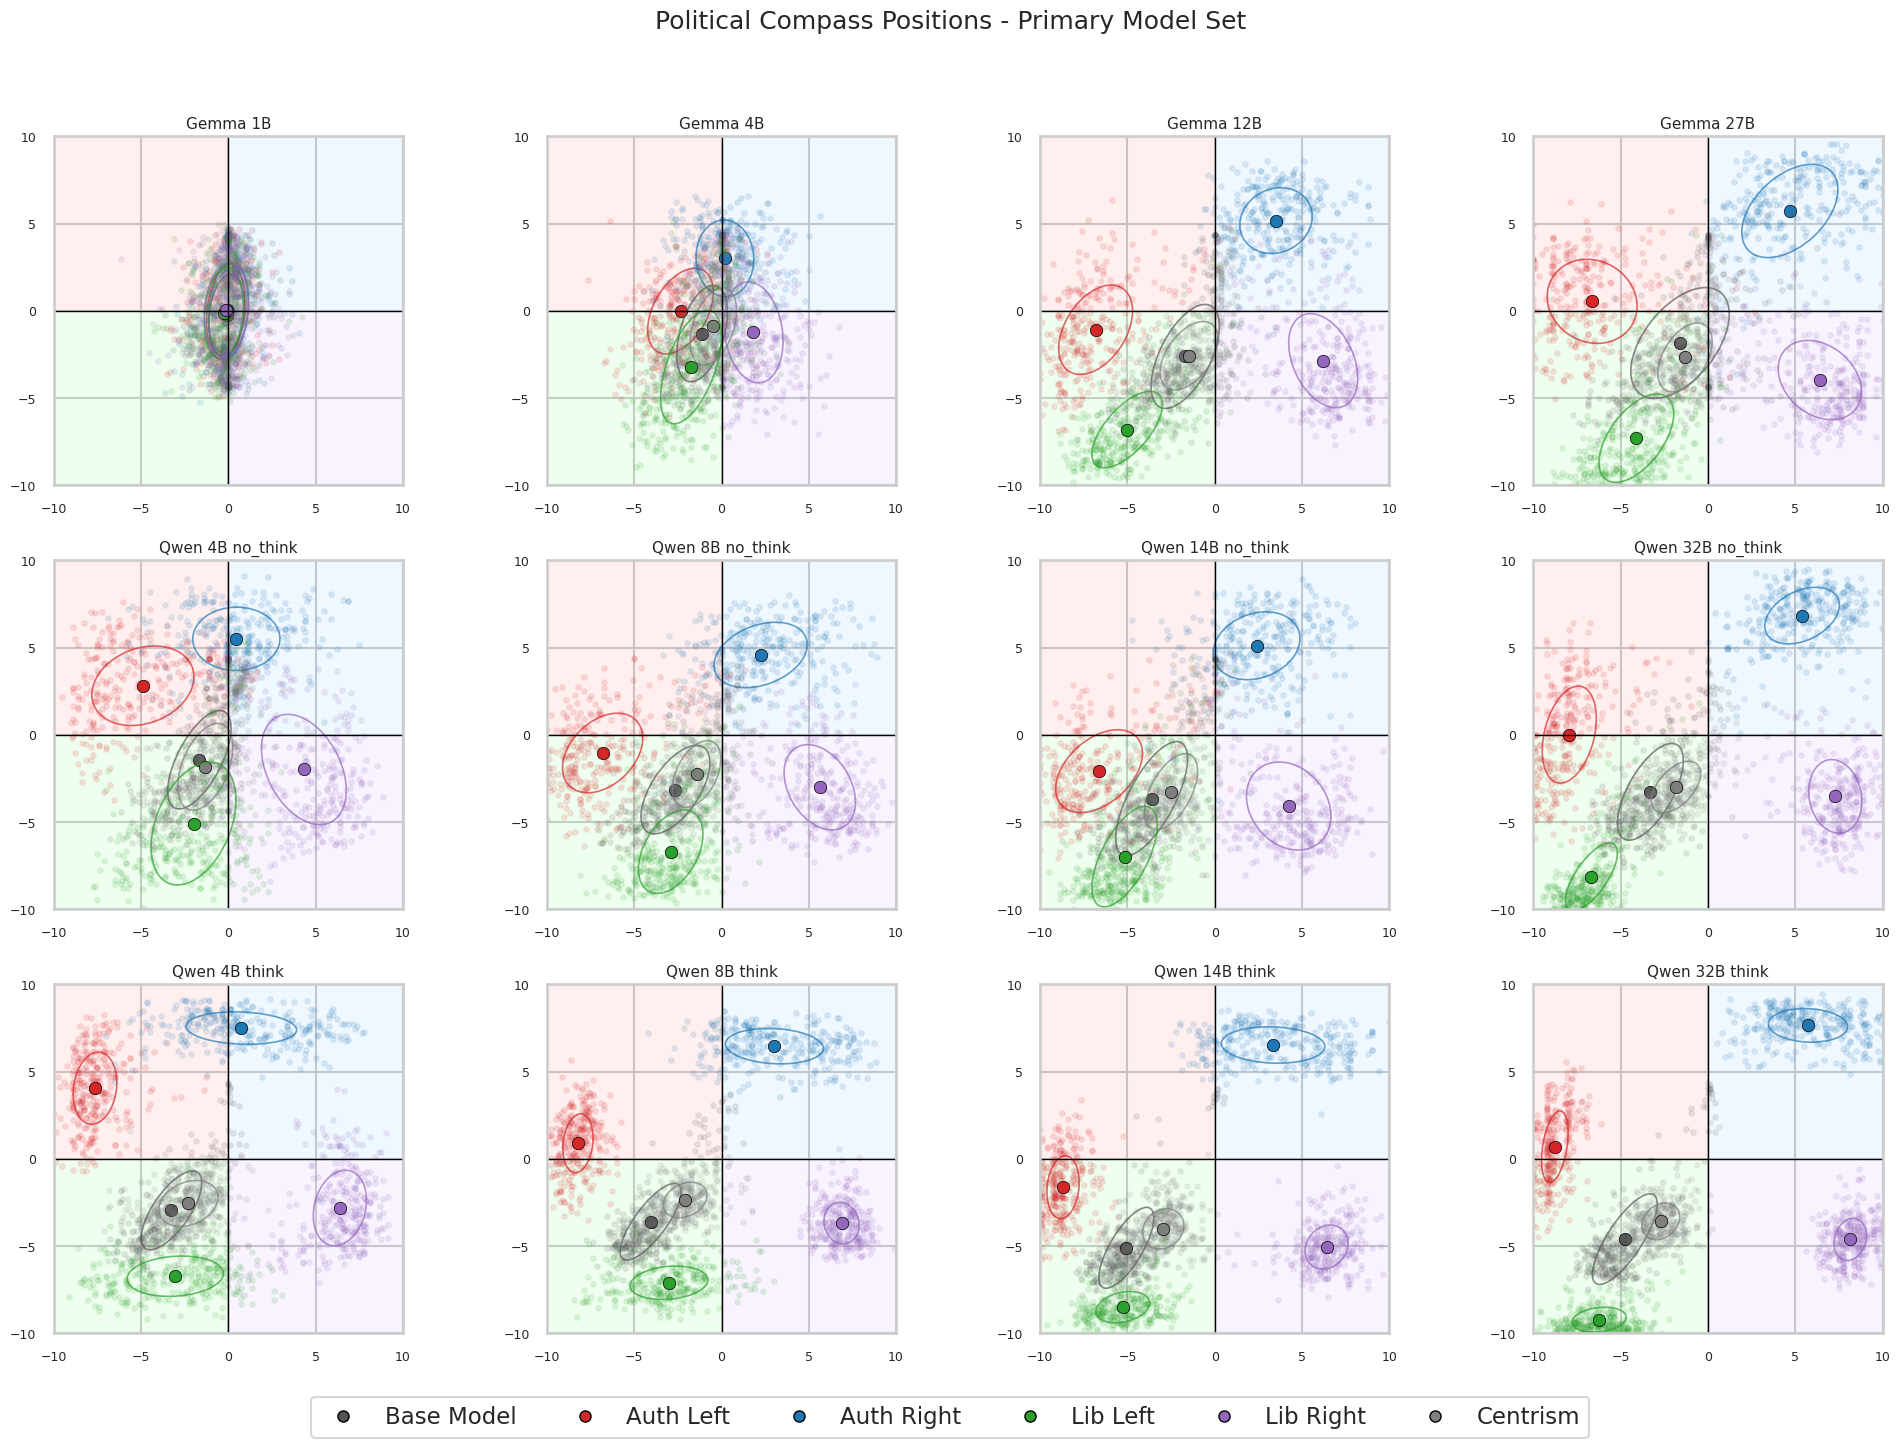

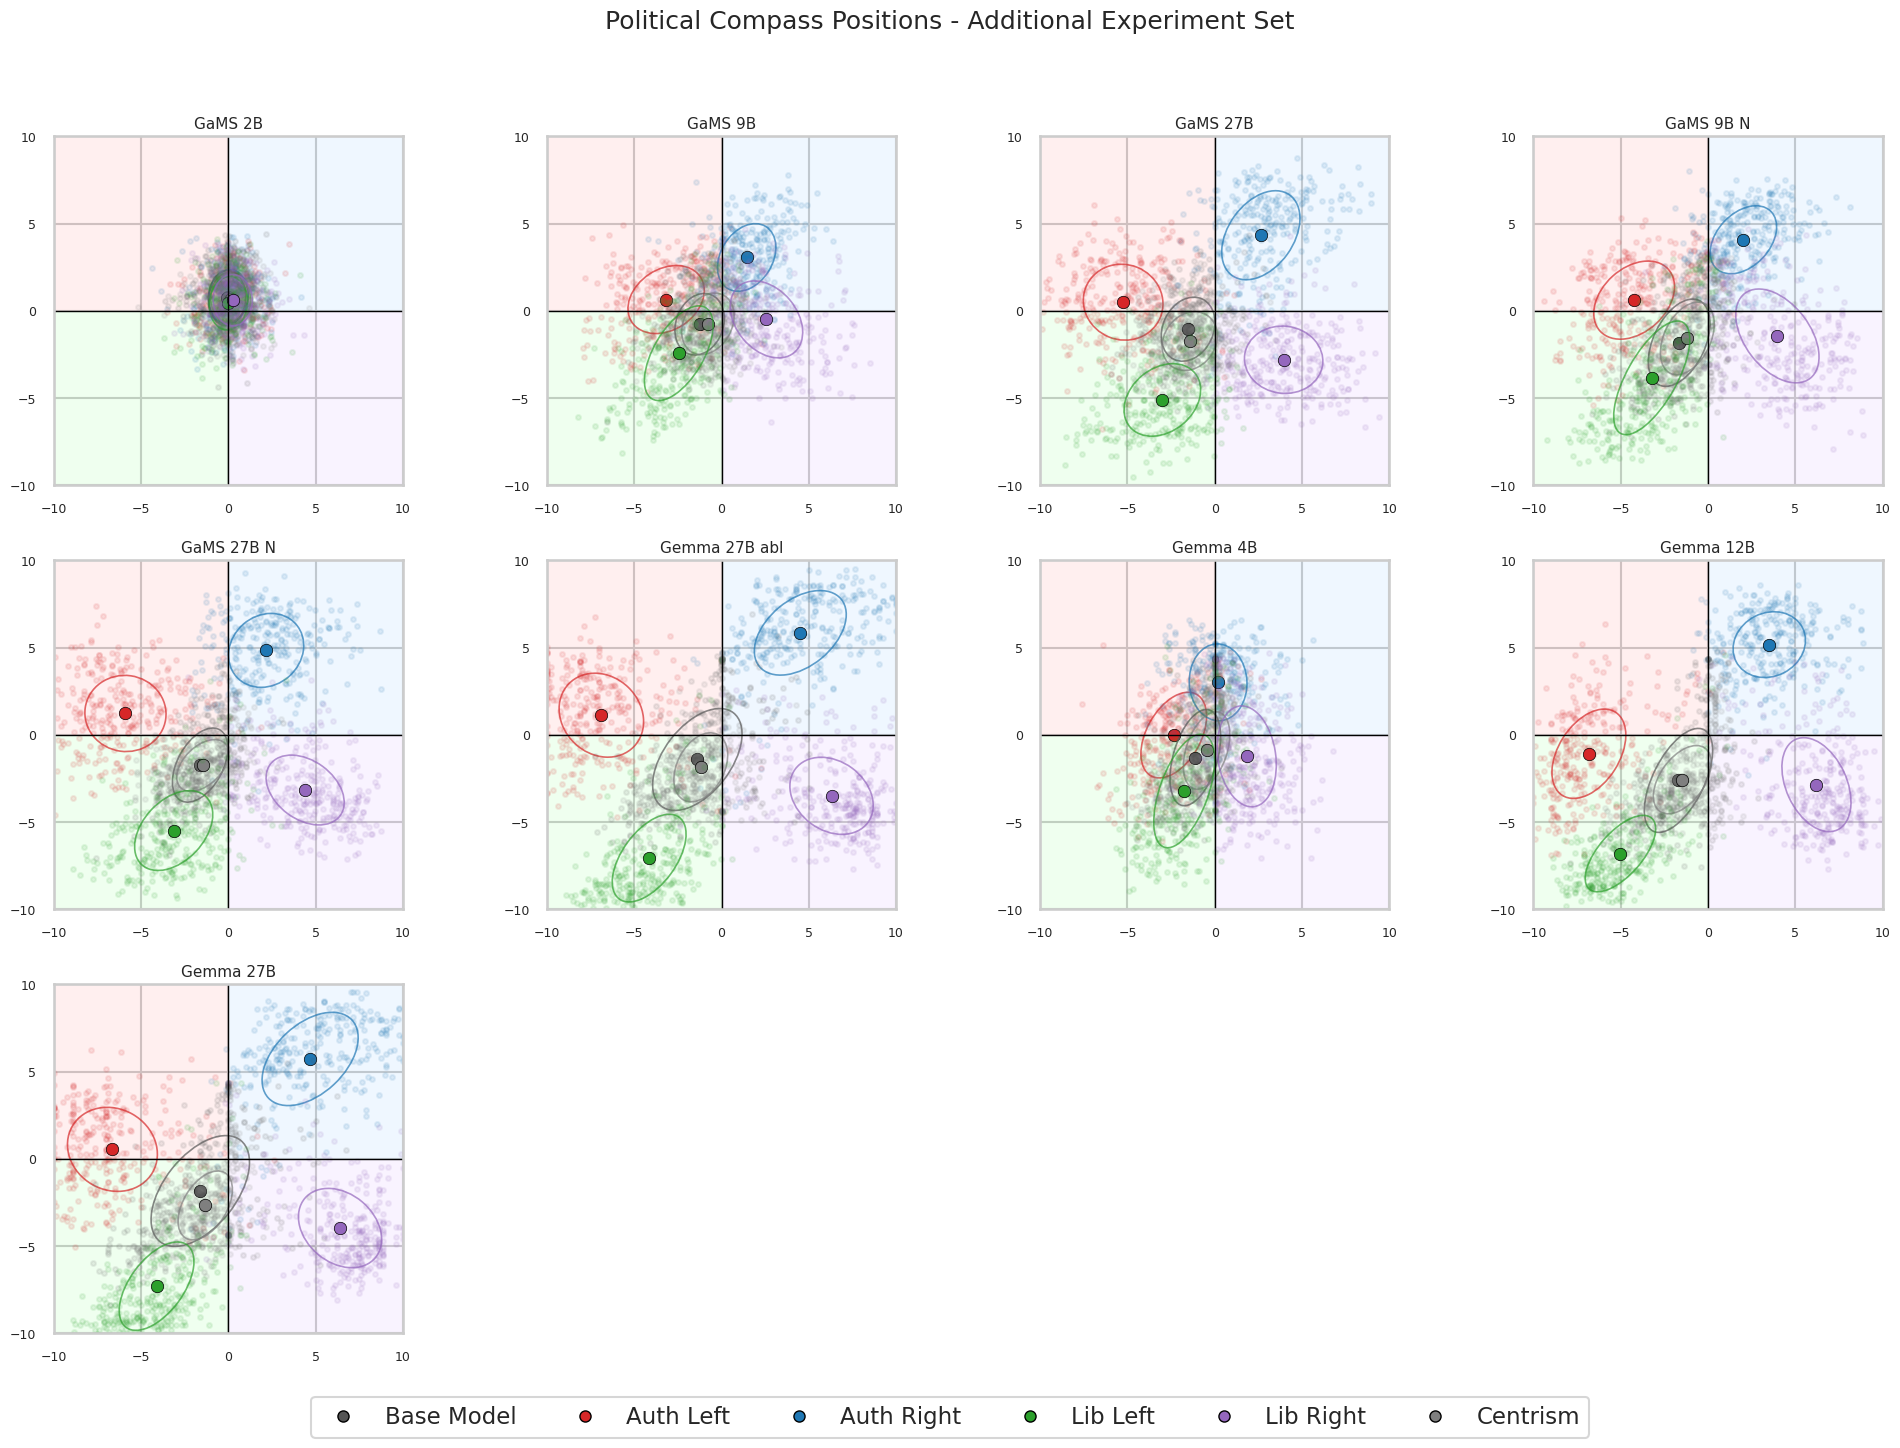

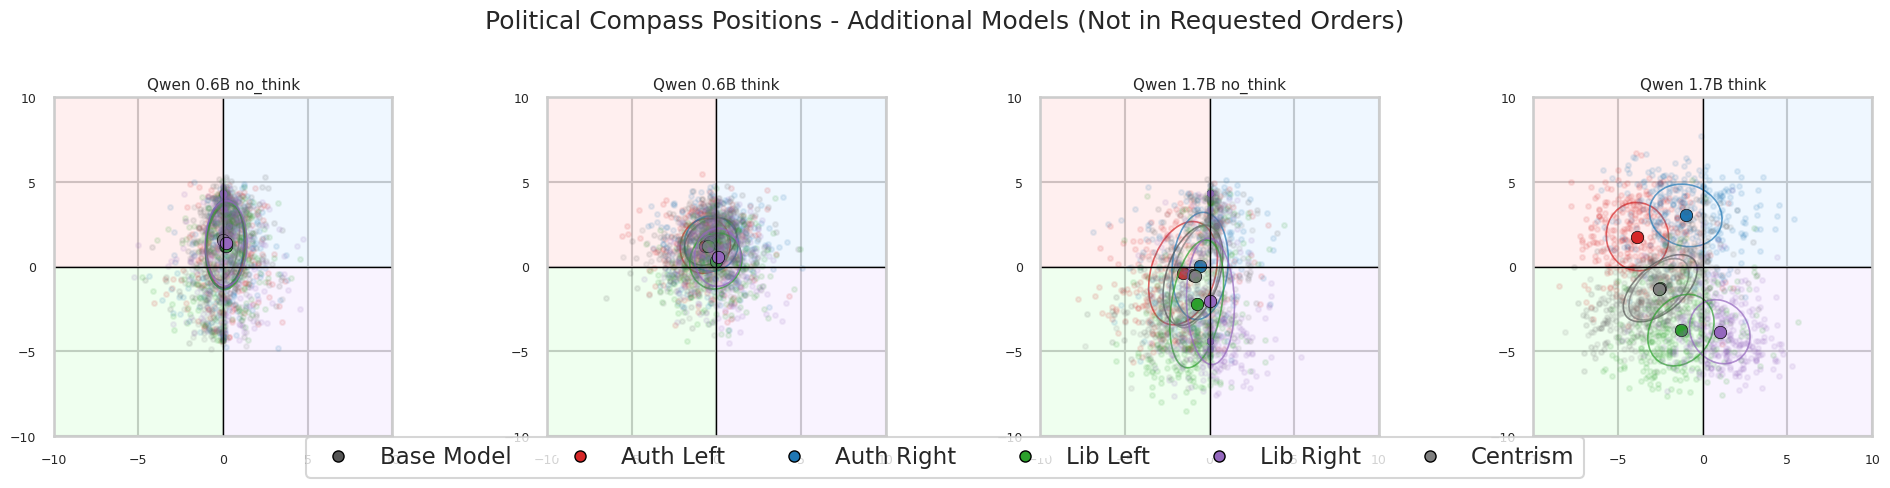

In [8]:
available_models = set(score_df['model_variant'].astype(str).unique())


def plot_compass_grid(model_list, title, output_name):
    models = [m for m in model_list if m in available_models]
    if not models:
        print(f'No models available for {title}')
        return

    cols = 4
    rows = math.ceil(len(models) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.atleast_1d(axes).reshape(rows, cols)

    for ax in axes.flat:
        ax.set_visible(False)

    for ax, model_variant in zip(axes.flat, models):
        ax.set_visible(True)
        draw_background(ax)
        sub = score_df[score_df['model_variant'] == model_variant].copy()
        ax.set_title(display_model_label(model_variant), fontsize=11)
        for ideology, ide_df in sub.groupby('ideology'):
            label = DISPLAY_NAMES.get(ideology, ideology)
            color = IDEOLOGY_COLORS.get(label, '#333333')
            ax.scatter(ide_df['score_econ'], ide_df['score_soc'], s=12, alpha=0.10, color=color)
            ax.scatter(
                ide_df['score_econ'].mean(),
                ide_df['score_soc'].mean(),
                s=80,
                color=color,
                edgecolor='black',
                linewidth=0.5,
            )
            confidence_ellipse(
                ide_df['score_econ'],
                ide_df['score_soc'],
                ax,
                n_std=1.0,
                edgecolor=color,
                linewidth=1.2,
                alpha=0.7,
            )

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markeredgecolor='black', markersize=8, label=label)
        for label, color in IDEOLOGY_COLORS.items()
    ]
    fig.legend(handles=handles, loc='lower center', ncol=6, bbox_to_anchor=(0.5, 0.02), frameon=True)
    fig.suptitle(title, fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0.06, 1, 0.96])
    plt.savefig(PLOTS_DIR / output_name, dpi=200, bbox_inches='tight')
    plt.show()


plot_compass_grid(
    GENERAL_MODEL_ORDER_1,
    'Political Compass Positions - Primary Model Set',
    '03a_compass_grid_primary.png',
)

plot_compass_grid(
    GENERAL_MODEL_ORDER_2,
    'Political Compass Positions - Additional Experiment Set',
    '03b_compass_grid_additional.png',
)

extras = [
    model
    for model in ordered_model_variants(score_df['model_variant'].unique(), order='general')
    if model not in set(GENERAL_MODEL_ORDER_1) and model not in set(GENERAL_MODEL_ORDER_2)
]

if extras:
    plot_compass_grid(
        extras,
        'Political Compass Positions - Additional Models (Not in Requested Orders)',
        '03c_compass_grid_extras.png',
    )

In [9]:
paired = []
qwen_base_order = ['Qwen3-0.6B', 'Qwen3-1.7B', 'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B', 'Qwen3-32B']

for base_model in qwen_base_order:
    think_name = f'{base_model}_think'
    no_think_name = f'{base_model}_no_think'
    available = set(score_df['model_variant'].unique())
    if think_name not in available or no_think_name not in available:
        continue

    for ideology in sorted(score_df['ideology'].unique()):
        think_sub = score_df[(score_df['model_variant'] == think_name) & (score_df['ideology'] == ideology)]
        no_sub = score_df[(score_df['model_variant'] == no_think_name) & (score_df['ideology'] == ideology)]
        if think_sub.empty or no_sub.empty:
            continue

        paired.append({
            'base_model': base_model,
            'model_size': short_model_label(base_model),
            'ideology': ideology,
            'ideology_label': DISPLAY_NAMES.get(ideology, ideology),
            'econ_no_think': no_sub['score_econ'].mean(),
            'soc_no_think': no_sub['score_soc'].mean(),
            'econ_think': think_sub['score_econ'].mean(),
            'soc_think': think_sub['score_soc'].mean(),
        })

paired_df = pd.DataFrame(paired)
paired_df

,base_model,model_size,ideology,ideology_label,econ_no_think,soc_no_think,econ_think,soc_think
0,Qwen3-0.6B,0.6B,authoritarian_left,Auth Left,0.155647,1.298037,-0.651813,1.232560
1,Qwen3-0.6B,0.6B,authoritarian_right,Auth Right,0.100662,1.338346,-0.296413,1.363200
2,Qwen3-0.6B,0.6B,base,Base Model,0.128135,1.231076,-0.345993,1.486241
3,Qwen3-0.6B,0.6B,centrism,Centrism,0.023131,1.559372,-0.489698,1.211115
4,Qwen3-0.6B,0.6B,libertarian_left,Lib Left,0.185280,1.207375,-0.026555,0.340406
5,Qwen3-0.6B,0.6B,libertarian_right,Lib Right,0.183408,1.387742,0.081705,0.558791
6,Qwen3-1.7B,1.7B,authoritarian_left,Auth Left,-1.567935,-0.376074,-3.857965,1.781451
7,Qwen3-1.7B,1.7B,authoritarian_right,Auth Right,-0.555523,0.050260,-1.007642,3.035693
8,Qwen3-1.7B,1.7B,base,Base Model,-0.983484,-0.507834,-2.513505,-1.264161
9,Qwen3-1.7B,1.7B,centrism,Centrism,-0.851571,-0.559179,-2.591952,-1.326103


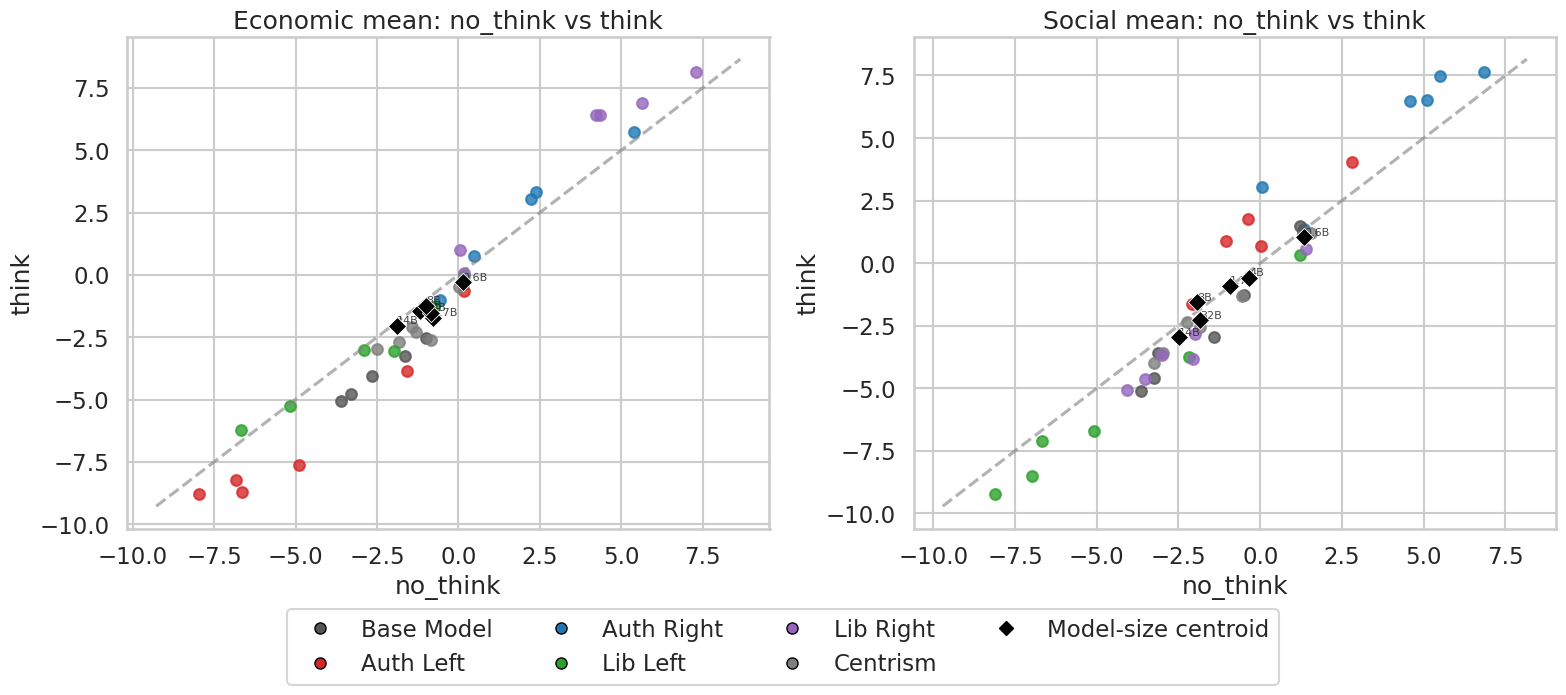

In [10]:
if paired_df.empty:
    print('No think / no_think pairs available.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=False, sharey=False)
    panel_specs = [
        ('econ_no_think', 'econ_think', 'Economic mean: no_think vs think'),
        ('soc_no_think', 'soc_think', 'Social mean: no_think vs think'),
    ]

    for ax, (x_col, y_col, title) in zip(axes, panel_specs):
        lims = [
            min(paired_df[x_col].min(), paired_df[y_col].min()) - 0.5,
            max(paired_df[x_col].max(), paired_df[y_col].max()) + 0.5,
        ]
        ax.plot(lims, lims, '--', color='gray', alpha=0.6)

        for ideology_label, ide_sub in paired_df.groupby('ideology_label'):
            color = IDEOLOGY_COLORS.get(ideology_label, '#333333')
            ax.scatter(ide_sub[x_col], ide_sub[y_col], color=color, s=60, alpha=0.80)

        # Label only per-size centroids to avoid clutter/overlap from repeated family names.
        for base_model, model_sub in paired_df.groupby('base_model'):
            cx = model_sub[x_col].mean()
            cy = model_sub[y_col].mean()
            ax.scatter(cx, cy, marker='D', color='black', s=85, edgecolor='white', linewidth=0.6, zorder=6)
            ax.text(cx, cy, short_model_label(base_model), fontsize=8, ha='left', va='bottom', alpha=0.85)

        ax.set_title(title)
        ax.set_xlabel('no_think')
        ax.set_ylabel('think')

    ideology_handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markeredgecolor='black', markersize=8, label=label)
        for label, color in IDEOLOGY_COLORS.items()
    ]
    centroid_handle = plt.Line2D([0], [0], marker='D', color='black', markerfacecolor='black', markersize=7, linestyle='', label='Model-size centroid')
    fig.legend(handles=ideology_handles + [centroid_handle], loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02), frameon=True)

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig(PLOTS_DIR / '04_think_vs_no_think.png', dpi=200, bbox_inches='tight')
    plt.show()

In [11]:
def _between_group_ss(sub_df: pd.DataFrame, factor: str, target_col: str) -> float:
    grouped = sub_df.groupby(factor, dropna=False)[target_col]
    means = grouped.mean()
    counts = grouped.count()
    grand_mean = sub_df[target_col].mean()
    ss = float(((means - grand_mean) ** 2 * counts).sum())
    if not np.isfinite(ss):
        return 0.0
    return max(ss, 0.0)


def _pick_factor_spec(model_df: pd.DataFrame, granularity: str = 'auto', chat_samples_per_block: int | None = None) -> tuple[list[str], dict[str, str], str]:
    detailed_factors = ['context_combo', 'instr_combo', 'reasoning_mode', 'persona_combo', 'key_type', 'perm_id', 'suffix_idx']
    detailed_labels = {
        'context_combo': 'Context',
        'instr_combo': 'Instruction',
        'reasoning_mode': 'Reasoning Mode',
        'persona_combo': 'Persona',
        'key_type': 'Key Type',
        'perm_id': 'Permutation',
        'suffix_idx': 'Suffix',
    }
    coarse_factors = ['context_combo', 'instr_type', 'reasoning_mode', 'persona_class', 'key_type', 'perm_id', 'suffix_idx']
    coarse_labels = {
        'context_combo': 'Context',
        'instr_type': 'Instruction Type',
        'reasoning_mode': 'Reasoning Mode',
        'persona_class': 'Persona Class',
        'key_type': 'Key Type',
        'perm_id': 'Permutation',
        'suffix_idx': 'Suffix',
    }

    if granularity == 'detailed':
        return detailed_factors, detailed_labels, 'detailed'
    if granularity == 'coarse':
        return coarse_factors, coarse_labels, 'coarse'

    if chat_samples_per_block is None:
        chat_samples_per_block = int(model_df.groupby('ideology').size().median())

    # For large blocks (v2-300), force detailed ANOVA to use richer factor resolution.
    if chat_samples_per_block >= 300:
        return detailed_factors, detailed_labels, 'detailed'

    # For smaller runs (e.g., v1-30), pick detailed only if residual DoF is adequate.
    min_residual_df = float('inf')
    for _, sub_df in model_df.groupby('ideology'):
        active = [f for f in detailed_factors if sub_df[f].nunique() > 1]
        model_df_used = 1 + sum(max(sub_df[f].nunique() - 1, 0) for f in active)
        residual_df = len(sub_df) - model_df_used
        min_residual_df = min(min_residual_df, residual_df)

    if min_residual_df >= 5:
        return detailed_factors, detailed_labels, 'detailed'
    return coarse_factors, coarse_labels, 'coarse'


def analyze_factor_sensitivity(
    df: pd.DataFrame,
    target_col: str,
    granularity: str = 'auto',
    chat_samples_per_block: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    results = []
    diagnostics = []

    for model_variant, model_df in df.groupby('model_variant'):
        factors, factor_labels, chosen_granularity = _pick_factor_spec(
            model_df,
            granularity=granularity,
            chat_samples_per_block=chat_samples_per_block,
        )
        total_n = len(model_df)
        ss_factors = {factor: 0.0 for factor in factors}
        ss_residual = 0.0
        df_residual = 0.0
        ideology_sd = model_df.groupby('ideology')[target_col].mean().std()
        n_fit_ok = 0
        n_fallback = 0

        for _, sub_df in model_df.groupby('ideology'):
            active_factors = [factor for factor in factors if sub_df[factor].nunique() > 1]
            if active_factors and len(sub_df) > (len(active_factors) + 1):
                formula = f"{target_col} ~ " + ' + '.join([f"C({factor})" for factor in active_factors])
                try:
                    fit = ols(formula, data=sub_df).fit()
                    table = anova_lm(fit, typ=2)
                    for factor in active_factors:
                        key = f"C({factor})"
                        if key in table.index:
                            ss_factors[factor] += float(table.loc[key, 'sum_sq'])
                    if 'Residual' in table.index:
                        ss_residual += float(table.loc['Residual', 'sum_sq'])
                        df_residual += float(table.loc['Residual', 'df'])
                    n_fit_ok += 1
                    continue
                except Exception:
                    pass

            # Robust fallback for underpowered or singular sub-blocks.
            n_fallback += 1
            for factor in active_factors:
                ss_factors[factor] += _between_group_ss(sub_df, factor, target_col)
            var = sub_df[target_col].var()
            if pd.isna(var):
                var = 0.0
            ss_residual += float(var) * max(len(sub_df) - 1, 1)
            df_residual += max(len(sub_df) - 1, 1)

        residual_sd = np.sqrt(ss_residual / max(df_residual, 1))
        total_structural_ss = sum(ss_factors.values())

        diagnostics.append({
            'model_variant': model_variant,
            'dimension': target_col,
            'granularity': chosen_granularity,
            'fit_ok_ideologies': n_fit_ok,
            'fallback_ideologies': n_fallback,
            'total_ideologies': model_df['ideology'].nunique(),
            'fit_success_rate': n_fit_ok / max(model_df['ideology'].nunique(), 1),
        })

        for factor in factors:
            results.append({
                'model_variant': model_variant,
                'dimension': target_col,
                'factor': factor,
                'factor_label': factor_labels[factor],
                'granularity': chosen_granularity,
                'sd_equivalent': np.sqrt(ss_factors[factor] / max(total_n, 1)),
                'share_of_structural_ss': ss_factors[factor] / total_structural_ss if total_structural_ss > 0 else 0.0,
                'ideology_sd': ideology_sd,
                'residual_sd': residual_sd,
            })

    return pd.DataFrame(results), pd.DataFrame(diagnostics)


ANOVA_GRANULARITY = 'detailed' if CHAT_SAMPLES_PER_BLOCK >= 300 else 'auto'

anova_econ, diag_econ = analyze_factor_sensitivity(
    score_df,
    'score_econ',
    granularity=ANOVA_GRANULARITY,
    chat_samples_per_block=CHAT_SAMPLES_PER_BLOCK,
)
anova_soc, diag_soc = analyze_factor_sensitivity(
    score_df,
    'score_soc',
    granularity=ANOVA_GRANULARITY,
    chat_samples_per_block=CHAT_SAMPLES_PER_BLOCK,
)
anova_df = pd.concat([anova_econ, anova_soc], ignore_index=True)
sensitivity_diag_df = pd.concat([diag_econ, diag_soc], ignore_index=True)

fallback_rows = sensitivity_diag_df[sensitivity_diag_df['fallback_ideologies'] > 0].copy()

print(f'Detected CHAT_SAMPLES_PER_BLOCK={CHAT_SAMPLES_PER_BLOCK}')
print(f'ANOVA granularity selected: {ANOVA_GRANULARITY}')
if fallback_rows.empty:
    print('ANOVA diagnostics: no fallback blocks were needed.')
else:
    print('ANOVA diagnostics: fallback was used in some blocks (see table below).')
    display(
        fallback_rows[
            ['model_variant', 'dimension', 'granularity', 'fallback_ideologies', 'total_ideologies']
        ].sort_values(['dimension', 'model_variant'])
    )

sensitivity_diag_df.sort_values(['dimension', 'model_variant']).head(30)

Detected CHAT_SAMPLES_PER_BLOCK=300
ANOVA granularity selected: detailed
ANOVA diagnostics: no fallback blocks were needed.


,model_variant,dimension,granularity,fit_ok_ideologies,fallback_ideologies,total_ideologies,fit_success_rate
0,GaMS-27B-Instruct,score_econ,detailed,6,0,6,1.0
1,GaMS-27B-Instruct-Nemotron,score_econ,detailed,6,0,6,1.0
2,GaMS-2B-Instruct,score_econ,detailed,6,0,6,1.0
3,GaMS-9B-Instruct,score_econ,detailed,6,0,6,1.0
4,GaMS-9B-Instruct-Nemotron,score_econ,detailed,6,0,6,1.0
5,Qwen3-0.6B_no_think,score_econ,detailed,6,0,6,1.0
6,Qwen3-0.6B_think,score_econ,detailed,6,0,6,1.0
7,Qwen3-1.7B_no_think,score_econ,detailed,6,0,6,1.0
8,Qwen3-1.7B_think,score_econ,detailed,6,0,6,1.0
9,Qwen3-14B_no_think,score_econ,detailed,6,0,6,1.0


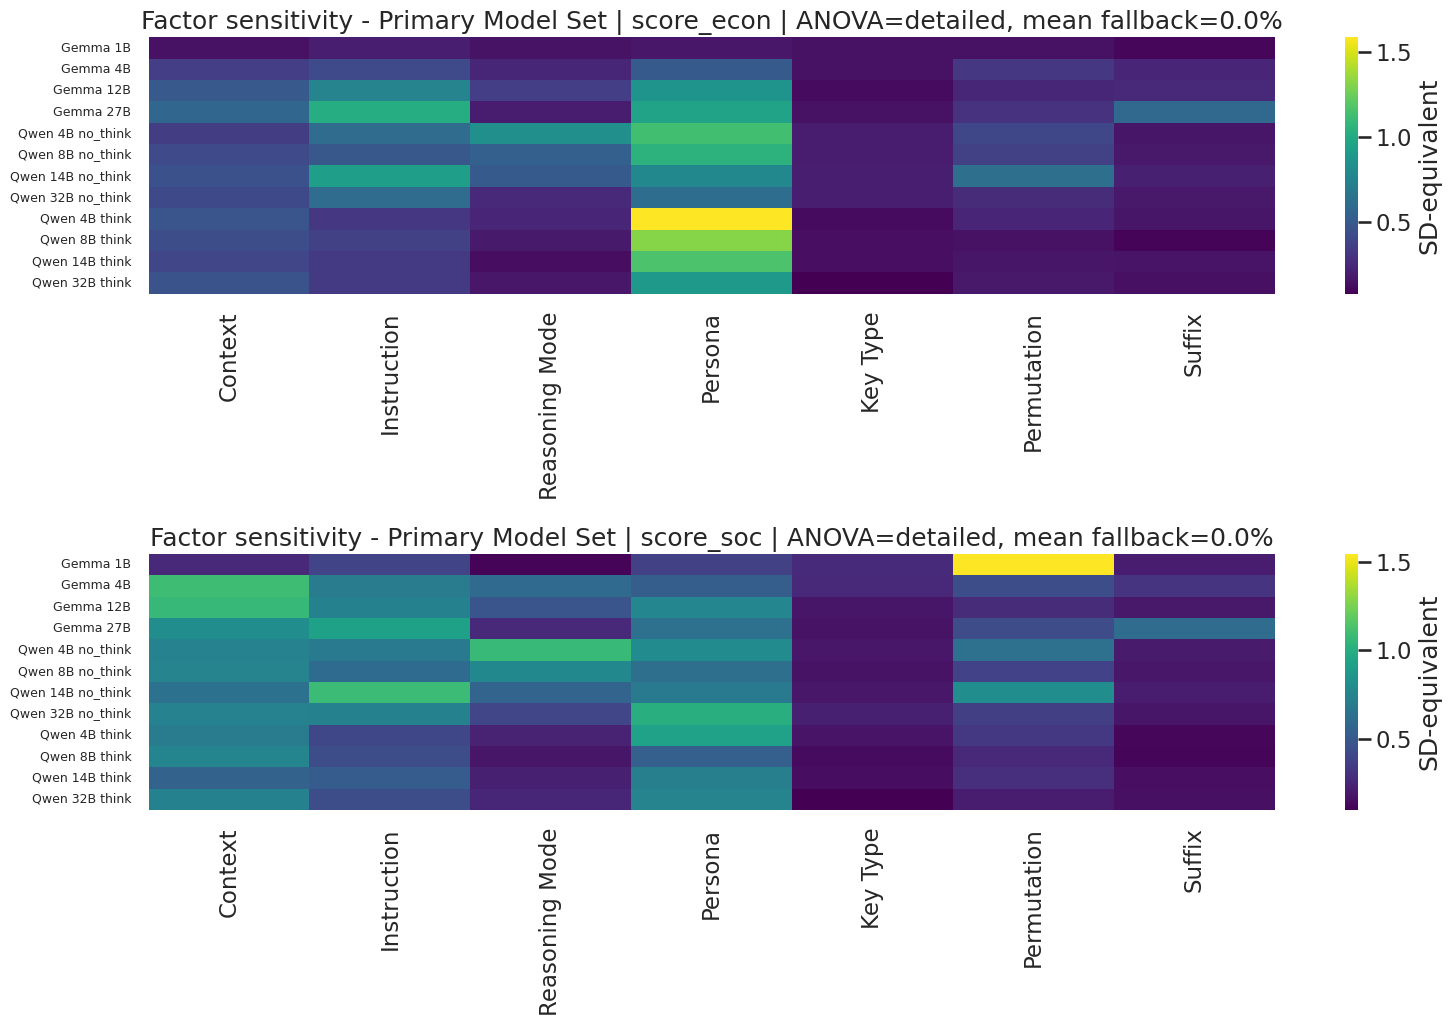

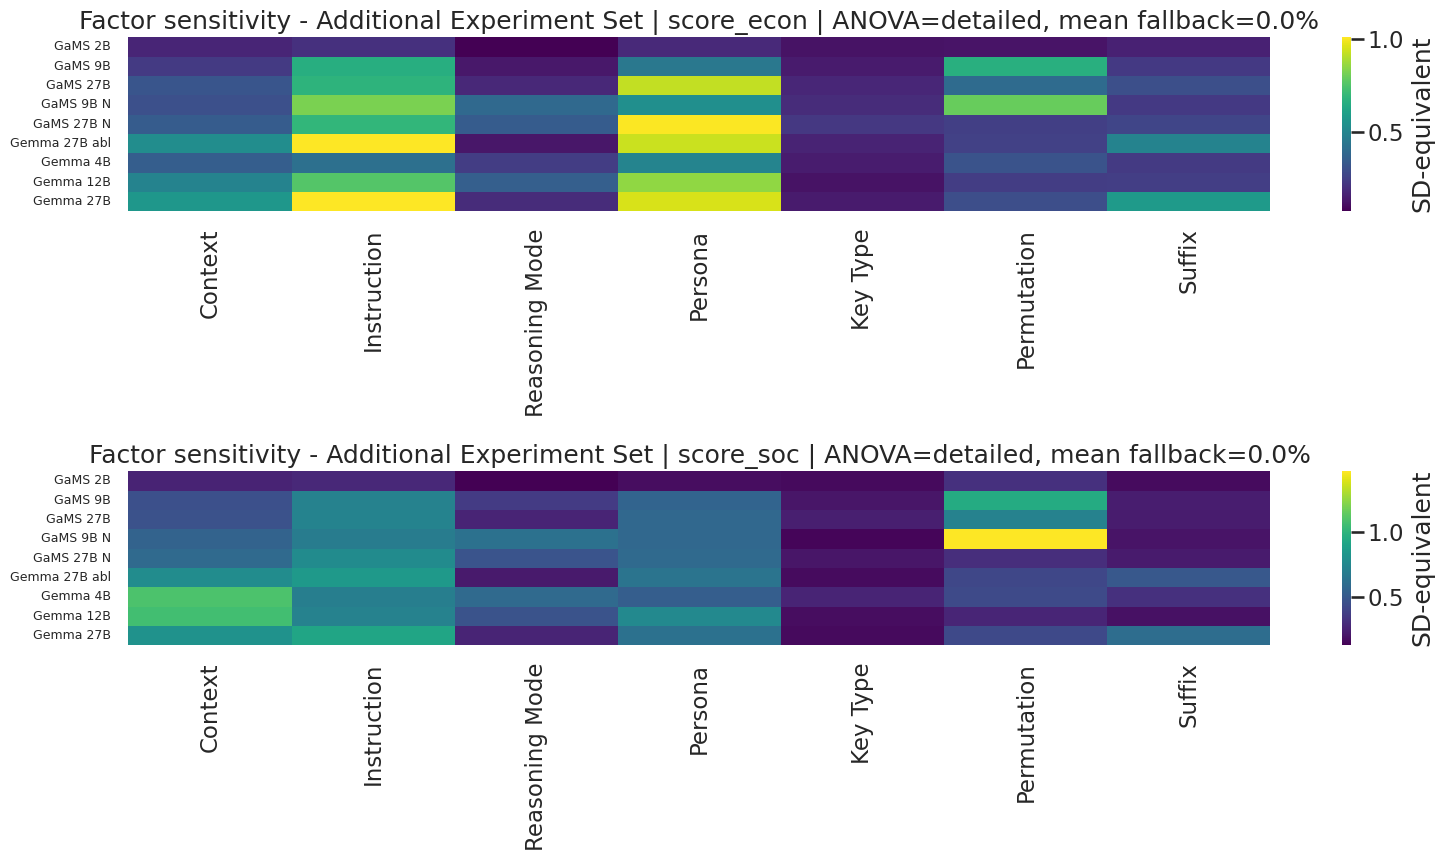

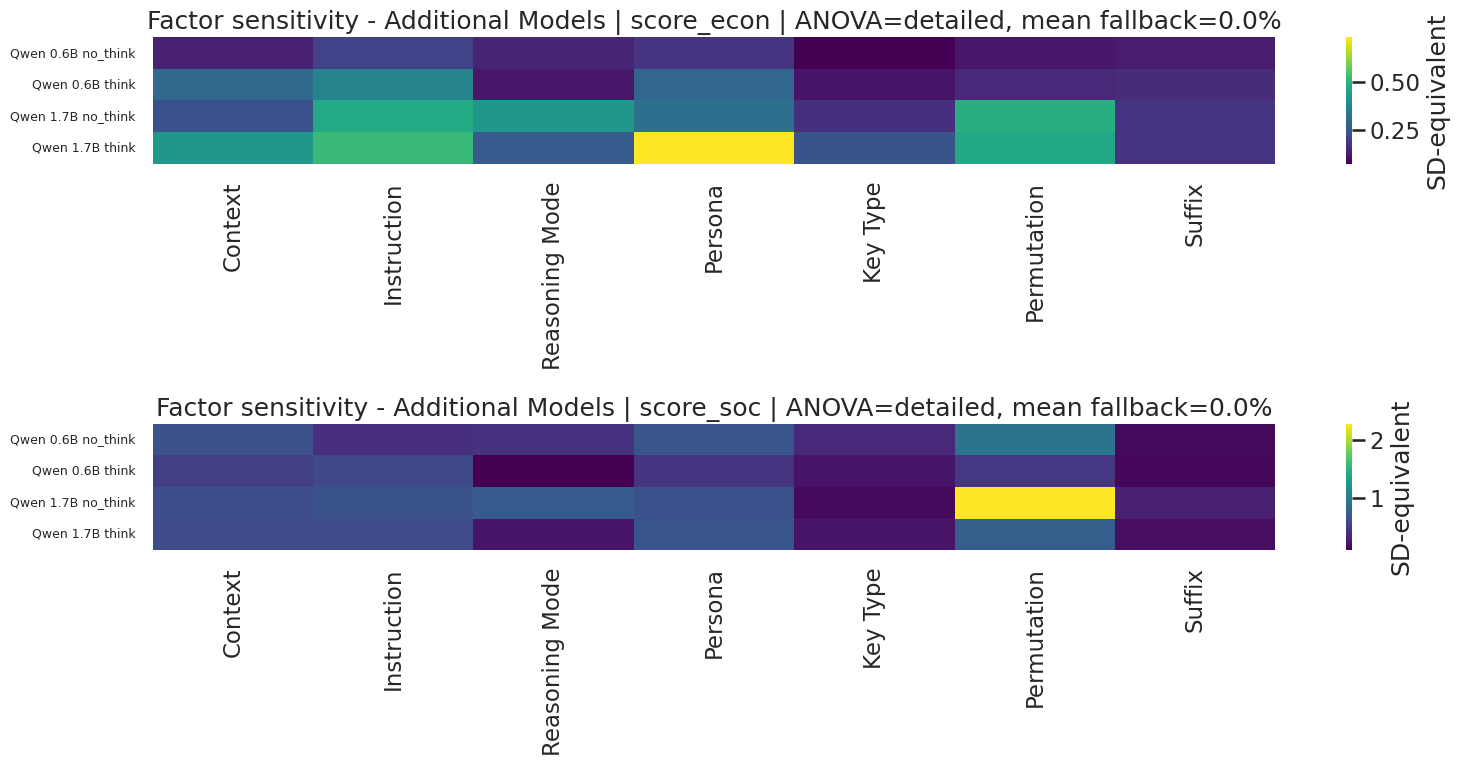

,model_variant,dimension,granularity,fit_ok_ideologies,fallback_ideologies,total_ideologies,fit_success_rate
0,gemma-3-1b-it,score_econ,detailed,6,0,6,1.0
1,gemma-3-4b-it,score_econ,detailed,6,0,6,1.0
2,gemma-3-12b-it,score_econ,detailed,6,0,6,1.0
3,gemma-3-27b-it,score_econ,detailed,6,0,6,1.0
4,Qwen3-4B_no_think,score_econ,detailed,6,0,6,1.0
5,Qwen3-8B_no_think,score_econ,detailed,6,0,6,1.0
6,Qwen3-14B_no_think,score_econ,detailed,6,0,6,1.0
7,Qwen3-32B_no_think,score_econ,detailed,6,0,6,1.0
8,Qwen3-4B_think,score_econ,detailed,6,0,6,1.0
9,Qwen3-8B_think,score_econ,detailed,6,0,6,1.0


In [12]:
def plot_factor_heatmap_group(model_order, group_name, output_name):
    models = [m for m in model_order if m in set(anova_df['model_variant'])]
    if not models:
        print(f'No ANOVA rows available for {group_name}')
        return

    fig_height = max(8, 0.55 * len(models) + 4)
    fig, axes = plt.subplots(2, 1, figsize=(16, fig_height), sharex=False)

    preferred_cols = [
        'Context',
        'Instruction',
        'Reasoning Mode',
        'Persona',
        'Key Type',
        'Permutation',
        'Suffix',
        'Instruction Type',
        'Persona Class',
    ]

    for ax, dim in zip(axes, ['score_econ', 'score_soc']):
        sub = anova_df[(anova_df['dimension'] == dim) & (anova_df['model_variant'].isin(models))].copy()
        if sub.empty:
            ax.text(0.5, 0.5, f'No rows for {dim}', ha='center', va='center')
            ax.set_axis_off()
            continue

        pivot = sub.pivot(index='model_variant', columns='factor_label', values='sd_equivalent').fillna(0)
        pivot = pivot.reindex(models)
        ordered_cols = [c for c in preferred_cols if c in pivot.columns] + [c for c in pivot.columns if c not in preferred_cols]
        pivot = pivot[ordered_cols]

        diag_sub = sensitivity_diag_df[
            (sensitivity_diag_df['dimension'] == dim) & (sensitivity_diag_df['model_variant'].isin(models))
        ]
        fallback_rate = 1.0 - diag_sub['fit_success_rate'].mean() if not diag_sub.empty else 0.0

        sns.heatmap(
            pivot,
            cmap='viridis',
            ax=ax,
            cbar_kws={'label': 'SD-equivalent'},
            yticklabels=[display_model_label(v) for v in pivot.index],
        )
        ax.set_title(
            f'{group_name} | {dim} | ANOVA={ANOVA_GRANULARITY}, mean fallback={fallback_rate:.1%}'
        )
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='y', labelsize=9)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / output_name, dpi=200, bbox_inches='tight')
    plt.show()


group1_models = [m for m in GENERAL_MODEL_ORDER_1 if m in set(anova_df['model_variant'])]
group2_models = [m for m in GENERAL_MODEL_ORDER_2 if m in set(anova_df['model_variant'])]

plot_factor_heatmap_group(
    group1_models,
    'Factor sensitivity - Primary Model Set',
    '05a_factor_sensitivity_heatmap_primary.png',
)

plot_factor_heatmap_group(
    group2_models,
    'Factor sensitivity - Additional Experiment Set',
    '05b_factor_sensitivity_heatmap_additional.png',
)

extra_models = [
    m for m in ordered_model_variants(anova_df['model_variant'].unique(), order='general')
    if m not in set(group1_models) and m not in set(group2_models)
]
if extra_models:
    plot_factor_heatmap_group(
        extra_models,
        'Factor sensitivity - Additional Models',
        '05c_factor_sensitivity_heatmap_extras.png',
    )

ordered_all = ordered_model_variants(sensitivity_diag_df['model_variant'].unique(), order='general')
sensitivity_diag_df = sensitivity_diag_df.assign(
    model_variant=pd.Categorical(
        sensitivity_diag_df['model_variant'],
        categories=ordered_all,
        ordered=True,
    )
).sort_values(['dimension', 'model_variant', 'fit_success_rate']).reset_index(drop=True)
sensitivity_diag_df

In [13]:
summary_table = (
    score_df.groupby(['model_variant', 'ideology'])
    .agg(
        econ_mean=('score_econ', 'mean'),
        econ_sd=('score_econ', 'std'),
        soc_mean=('score_soc', 'mean'),
        soc_sd=('score_soc', 'std'),
        mean_stage1_tokens=('mean_stage1_tokens', 'mean'),
        n_configs=('config_id', 'count'),
    )
    .reset_index()
)
summary_order = ordered_model_variants(summary_table['model_variant'].unique(), order='general')
summary_table = (
    summary_table.assign(model_variant=pd.Categorical(summary_table['model_variant'], categories=summary_order, ordered=True))
    .sort_values(['model_variant', 'ideology'])
    .reset_index(drop=True)
)
summary_table['model_variant'] = summary_table['model_variant'].astype(str)
summary_table.head(30)

,model_variant,ideology,econ_mean,econ_sd,soc_mean,soc_sd,mean_stage1_tokens,n_configs
0,gemma-3-1b-it,authoritarian_left,-0.146197,1.094775,-0.032196,2.735158,130.201505,300
1,gemma-3-1b-it,authoritarian_right,0.009318,1.140521,0.027494,2.747955,130.049409,300
2,gemma-3-1b-it,base,-0.092972,1.022117,-0.250276,2.354601,92.342581,300
3,gemma-3-1b-it,centrism,-0.053973,1.079812,0.011273,2.371661,143.561129,300
4,gemma-3-1b-it,libertarian_left,-0.261532,1.110501,-0.119366,2.643432,143.368548,300
5,gemma-3-1b-it,libertarian_right,-0.105063,1.264041,0.081344,2.707158,138.821667,300
6,gemma-3-4b-it,authoritarian_left,-2.349513,1.882323,-0.007884,2.453226,218.388602,300
7,gemma-3-4b-it,authoritarian_right,0.192152,1.653668,3.012707,2.202045,198.948172,300
8,gemma-3-4b-it,base,-1.114050,1.450041,-1.299144,2.755490,178.054516,300
9,gemma-3-4b-it,centrism,-0.468462,1.328993,-0.891252,2.219749,209.832527,300


In [14]:
def parse_family(model_variant: str) -> str:
    lower = str(model_variant).lower()
    if 'gemma' in lower:
        return 'gemma'
    if 'qwen' in lower:
        return 'qwen'
    if 'gams' in lower:
        return 'gams'
    return 'other'


def parse_size_b(model_variant: str) -> float:
    match = re.search(r'(\d+(?:\.\d+)?)[Bb]', str(model_variant))
    return float(match.group(1)) if match else np.nan


def parse_mode(model_variant: str) -> str:
    model_variant = str(model_variant)
    if model_variant.endswith('_think'):
        return 'think'
    if model_variant.endswith('_no_think'):
        return 'no_think'
    return 'standard'


def _fmt(value, digits=3):
    if pd.isna(value):
        return 'nan'
    return f"{float(value):.{digits}f}"


model_order_general = ordered_model_variants(summary_table['model_variant'].unique(), order='general')

# RQ1: baseline position of each model (ideology='base').
model_base = summary_table[summary_table['ideology'] == 'base'].copy()
model_base['distance_from_origin'] = np.sqrt(model_base['econ_mean'] ** 2 + model_base['soc_mean'] ** 2)
model_base['family'] = model_base['model_variant'].apply(parse_family)
model_base['size_b'] = model_base['model_variant'].apply(parse_size_b)
model_base['mode'] = model_base['model_variant'].apply(parse_mode)
model_base = (
    model_base.assign(model_variant=pd.Categorical(model_base['model_variant'], categories=model_order_general, ordered=True))
    .sort_values('model_variant')
    .reset_index(drop=True)
)
model_base['model_variant'] = model_base['model_variant'].astype(str)

# RQ2 / RQ7: strongest factors from ANOVA.
factor_rank = (
    anova_df.groupby(['dimension', 'factor_label'])['sd_equivalent']
    .mean()
    .reset_index()
    .sort_values(['dimension', 'sd_equivalent'], ascending=[True, False])
    .reset_index(drop=True)
)

# RQ6: ideology emulation distance from each model's own base point.
emulation_records = []
for model_variant, sub in summary_table.groupby('model_variant'):
    pivot = sub.set_index('ideology')
    if 'base' not in pivot.index:
        continue
    base_e = float(pivot.loc['base', 'econ_mean'])
    base_s = float(pivot.loc['base', 'soc_mean'])
    for ideology in ['authoritarian_left', 'authoritarian_right', 'libertarian_left', 'libertarian_right', 'centrism']:
        if ideology not in pivot.index:
            continue
        e = float(pivot.loc[ideology, 'econ_mean'])
        s = float(pivot.loc[ideology, 'soc_mean'])
        emulation_records.append(
            {
                'model_variant': model_variant,
                'ideology': ideology,
                'distance_from_base': float(np.sqrt((e - base_e) ** 2 + (s - base_s) ** 2)),
                'econ_mean': e,
                'soc_mean': s,
            }
        )
emulation_df = pd.DataFrame(emulation_records)

emulation_summary = (
    emulation_df.groupby('model_variant')['distance_from_base']
    .agg(mean_emulation_shift='mean', max_emulation_shift='max')
    .reset_index()
) if not emulation_df.empty else pd.DataFrame(columns=['model_variant', 'mean_emulation_shift', 'max_emulation_shift'])

expected_quadrant = {
    'authoritarian_left': (-1, +1),
    'authoritarian_right': (+1, +1),
    'libertarian_left': (-1, -1),
    'libertarian_right': (+1, -1),
    'centrism': (0, 0),
}


def sign_match(value: float, expected: int, tol: float = 0.35) -> bool:
    if expected == 0:
        return abs(value) <= tol
    if expected > 0:
        return value > tol
    return value < -tol


if not emulation_df.empty:
    emulation_df['econ_expected'] = emulation_df['ideology'].map(lambda x: expected_quadrant[x][0])
    emulation_df['soc_expected'] = emulation_df['ideology'].map(lambda x: expected_quadrant[x][1])
    emulation_df['econ_sign_match'] = emulation_df.apply(lambda r: sign_match(r['econ_mean'], int(r['econ_expected'])), axis=1)
    emulation_df['soc_sign_match'] = emulation_df.apply(lambda r: sign_match(r['soc_mean'], int(r['soc_expected'])), axis=1)
    emulation_df['quadrant_match'] = emulation_df['econ_sign_match'] & emulation_df['soc_sign_match']
    match_summary = (
        emulation_df.groupby('model_variant')['quadrant_match']
        .mean()
        .reset_index(name='quadrant_match_rate')
    )
else:
    match_summary = pd.DataFrame(columns=['model_variant', 'quadrant_match_rate'])

# RQ2: family/scale trend summaries.
family_summary = (
    model_base.groupby('family')
    .agg(
        mean_econ_base=('econ_mean', 'mean'),
        mean_soc_base=('soc_mean', 'mean'),
        mean_bias_distance=('distance_from_origin', 'mean'),
        n_models=('model_variant', 'count'),
    )
    .reset_index()
)

scale_corr_rows = []
for family, fam_sub in model_base.groupby('family'):
    if fam_sub['size_b'].nunique() < 2:
        corr = np.nan
    else:
        corr = fam_sub['size_b'].corr(fam_sub['distance_from_origin'])
    scale_corr_rows.append({'family': family, 'corr_size_vs_bias_distance': corr})
scale_corr = pd.DataFrame(scale_corr_rows)

# RQ5: think vs no_think relation.
if not paired_df.empty:
    think_delta_summary = (
        paired_df.assign(
            delta_econ=paired_df['econ_think'] - paired_df['econ_no_think'],
            delta_soc=paired_df['soc_think'] - paired_df['soc_no_think'],
        )
        .groupby('base_model')
        .agg(
            mean_delta_econ=('delta_econ', 'mean'),
            mean_abs_delta_econ=('delta_econ', lambda s: np.mean(np.abs(s))),
            mean_delta_soc=('delta_soc', 'mean'),
            mean_abs_delta_soc=('delta_soc', lambda s: np.mean(np.abs(s))),
        )
        .reset_index()
    )
else:
    think_delta_summary = pd.DataFrame(
        columns=['base_model', 'mean_delta_econ', 'mean_abs_delta_econ', 'mean_delta_soc', 'mean_abs_delta_soc']
    )

# RQ3 evidence: language coverage for this run.
language_summary = (
    design_df.groupby('language')
    .size()
    .reset_index(name='n_configs')
    .sort_values('n_configs', ascending=False)
    .reset_index(drop=True)
)

# RQ4 evidence: this notebook only loads chat-v2-300.
mcq_dir = ROOT / 'output' / 'mcq'
mcq_available = mcq_dir.exists()

diag_summary = (
    sensitivity_diag_df.groupby('dimension')
    .agg(
        mean_fit_success_rate=('fit_success_rate', 'mean'),
        max_fallback_ideologies=('fallback_ideologies', 'max'),
        mean_fallback_ideologies=('fallback_ideologies', 'mean'),
    )
    .reset_index()
)

print('Evidence tables used for conclusions')
print('RQ1 baseline table:')
display(model_base[['model_variant', 'econ_mean', 'soc_mean', 'distance_from_origin', 'mean_stage1_tokens']])

print('RQ2/RQ7 factor sensitivity ranking (mean SD-equivalent):')
display(factor_rank)

print('RQ6 emulation diagnostics:')
display(emulation_summary)
display(match_summary)

print('RQ2 family and size trends:')
display(family_summary)
display(scale_corr)

print('RQ5 think vs no_think deltas:')
display(think_delta_summary)

print('RQ3 language coverage in this run:')
display(language_summary)

print('ANOVA diagnostics:')
display(diag_summary)

rq_lines = []

# RQ1
if not model_base.empty:
    top_bias = model_base.sort_values('distance_from_origin', ascending=False).iloc[0]
    rq_lines.append(
        f"RQ1: Open-weight models show non-zero baseline political displacement in this run; max is {top_bias['model_variant']} with distance {_fmt(top_bias['distance_from_origin'])}."
    )
else:
    rq_lines.append('RQ1: No baseline rows available in this run.')

# RQ2
if not family_summary.empty:
    fam_text = '; '.join(
        f"{row.family}: mean_bias_distance={_fmt(row.mean_bias_distance)} (n={int(row.n_models)})"
        for row in family_summary.itertuples(index=False)
    )
    corr_text = '; '.join(
        f"{row.family}: corr(size,bias_dist)={_fmt(row.corr_size_vs_bias_distance)}"
        for row in scale_corr.itertuples(index=False)
    )
    rq_lines.append('RQ2: Family/scale differences are visible in v2-300. Family means -> ' + fam_text + '.')
    rq_lines.append('RQ2 (size trend evidence): ' + corr_text + '.')
else:
    rq_lines.append('RQ2: Family/scale summary unavailable.')

# RQ3
n_languages = int(language_summary['language'].nunique()) if not language_summary.empty else 0
if n_languages <= 1:
    rq_lines.append(
        'RQ3: Distributional language differences cannot be estimated here because chat-v2-300 contains one language only (see language_summary table).'
    )
else:
    rq_lines.append(
        f'RQ3: Multiple languages are present (n={n_languages}); language-conditioned comparisons can be estimated from this run.'
    )

# RQ4
if mcq_available:
    rq_lines.append(
        'RQ4: MCQ-vs-chat comparison is not computed in this notebook; MCQ artifacts exist but require a joined analysis table.'
    )
else:
    rq_lines.append(
        'RQ4: MCQ-vs-chat comparison is not computed in this notebook because only chat-v2-300 outputs are loaded.'
    )

# RQ5
if not think_delta_summary.empty:
    think_text = '; '.join(
        f"{row.base_model}: |delta_econ|={_fmt(row.mean_abs_delta_econ)}, |delta_soc|={_fmt(row.mean_abs_delta_soc)}"
        for row in think_delta_summary.itertuples(index=False)
    )
    rq_lines.append('RQ5: Thinking vs non-thinking produces non-zero, model-dependent shifts -> ' + think_text + '.')
else:
    rq_lines.append('RQ5: No think/no_think pairs available in this run.')

# RQ6
if not emulation_summary.empty:
    best_emulation = emulation_summary.sort_values('mean_emulation_shift', ascending=False).iloc[0]
    rq_lines.append(
        f"RQ6: Models can emulate persona-conditioned quadrants; largest mean shift from base is {best_emulation['model_variant']} at {_fmt(best_emulation['mean_emulation_shift'])}."
    )
else:
    rq_lines.append('RQ6: Emulation summary unavailable.')

if not match_summary.empty:
    best_match = match_summary.sort_values('quadrant_match_rate', ascending=False).iloc[0]
    rq_lines.append(
        f"RQ6 (quadrant fidelity): best quadrant-match rate is {best_match['model_variant']} at {_fmt(best_match['quadrant_match_rate'] * 100.0, 1)}%."
    )

# RQ7
if not factor_rank.empty:
    top_factors = (
        factor_rank.groupby('dimension').head(2)[['dimension', 'factor_label', 'sd_equivalent']]
        .apply(lambda r: f"{r['dimension']}: {r['factor_label']} ({_fmt(r['sd_equivalent'])})", axis=1)
        .tolist()
    )
    rq_lines.append(
        'RQ7: Prompt/sampling/design factors have measurable effects; strongest mean factors -> ' + '; '.join(top_factors) + '.'
    )
else:
    rq_lines.append('RQ7: Factor ranking unavailable.')

max_fallback = int(sensitivity_diag_df['fallback_ideologies'].max()) if not sensitivity_diag_df.empty else -1
rq_lines.append(
    f'ANOVA evidence: CHAT_SAMPLES_PER_BLOCK={CHAT_SAMPLES_PER_BLOCK}, mode={ANOVA_GRANULARITY}, max fallback ideologies={max_fallback}.'
)

print('\nConclusions with evidence (chat-v2-300)')
print('\n'.join(rq_lines))

Evidence tables used for conclusions
RQ1 baseline table:


,model_variant,econ_mean,soc_mean,distance_from_origin,mean_stage1_tokens
0,gemma-3-1b-it,-0.092972,-0.250276,0.266987,92.342581
1,gemma-3-4b-it,-1.114050,-1.299144,1.711398,178.054516
2,gemma-3-12b-it,-1.691400,-2.605040,3.105973,221.656935
3,gemma-3-27b-it,-1.603202,-1.835292,2.436915,232.944839
4,Qwen3-4B_no_think,-1.654006,-1.419690,2.179738,142.385215
5,Qwen3-8B_no_think,-2.638305,-3.132847,4.095777,156.817849
6,Qwen3-14B_no_think,-3.617801,-3.648141,5.137842,135.920215
7,Qwen3-32B_no_think,-3.300371,-3.258182,4.637693,136.721452
8,Qwen3-4B_think,-3.254694,-2.945902,4.389917,989.285591
9,Qwen3-8B_think,-4.056701,-3.596383,5.421328,909.304892


RQ2/RQ7 factor sensitivity ranking (mean SD-equivalent):


,dimension,factor_label,sd_equivalent
0,score_econ,Persona,0.751001
1,score_econ,Instruction,0.544407
2,score_econ,Context,0.360974
3,score_econ,Permutation,0.321379
4,score_econ,Reasoning Mode,0.270659
5,score_econ,Suffix,0.216173
6,score_econ,Key Type,0.156095
7,score_soc,Permutation,0.658170
8,score_soc,Context,0.646634
9,score_soc,Persona,0.629219


RQ6 emulation diagnostics:


...

RQ3 language coverage in this run:


,language,n_configs
0,english,39600


ANOVA diagnostics:


,dimension,mean_fit_success_rate,max_fallback_ideologies,mean_fallback_ideologies
0,score_econ,1.0,0,0.0
1,score_soc,1.0,0,0.0



Conclusions with evidence (chat-v2-300)
RQ1: Open-weight models show non-zero baseline political displacement in this run; max is Qwen3-14B_think with distance 7.181.
RQ2: Family/scale differences are visible in v2-300. Family means -> gams: mean_bias_distance=1.777 (n=5); gemma: mean_bias_distance=1.899 (n=5); qwen: mean_bias_distance=3.862 (n=12).
RQ2 (size trend evidence): gams: corr(size,bias_dist)=0.590; gemma: corr(size,bias_dist)=0.549; qwen: corr(size,bias_dist)=0.690.
RQ3: Distributional language differences cannot be estimated here because chat-v2-300 contains one language only (see language_summary table).
RQ4: MCQ-vs-chat comparison is not computed in this notebook because only chat-v2-300 outputs are loaded.
RQ5: Thinking vs non-thinking produces non-zero, model-dependent shifts -> Qwen3-0.6B: |delta_econ|=0.418, |delta_soc|=0.398; Qwen3-1.7B: |delta_econ|=1.249, |delta_soc|=1.669; Qwen3-14B: |delta_econ|=1.195, |delta_soc|=1.095; Qwen3-32B: |delta_econ|=0.800, |delta_soc

## Notes

- This notebook intentionally mirrors the v1-30 flow but targets `output/chat-v2-300`.
- Model ordering is split into `GENERAL_MODEL_ORDER_1` (primary) and `GENERAL_MODEL_ORDER_2` (additional experiments).
- Compass and ANOVA heatmaps are rendered by model groups to reduce label overlap and improve readability.
- Stage-2 probabilities remain the source of truth for scoring; stage-1 text/token statistics are diagnostics.
- ANOVA granularity is now sample-size aware: `detailed` is selected for `CHAT_SAMPLES_PER_BLOCK >= 300`.
- The conclusion cell reports evidence-backed statements and explicitly flags which research questions cannot be answered from chat-only v2 data.